<h1 style="
    background: linear-gradient(135deg, #4A148C, #7B1FA2, #E91E63);
    color: #FFFFFF;
    padding: 24px;
    border-radius: 18px;
    text-align: center;
    font-size: 34px;
    font-weight: 700;
    box-shadow: 0 8px 25px rgba(74, 20, 140, 0.35);
    letter-spacing: 1.2px;
    border: 1px solid rgba(255,255,255,0.15);
">
    DengAI - Data Understanding
</h1>

In [7]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

3.0.5
2.4.6


In [8]:
features_train = pd.read_csv("../data/raw/dengue_features_train.csv")
labels_train = pd.read_csv("../data/raw/dengue_labels_train.csv")
features_test = pd.read_csv("../data/raw/dengue_features_test.csv")
submission = pd.read_csv("../data/raw/submission_format.csv")

In [9]:
features_train.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [10]:
labels_train.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,4
1,sj,1990,19,5
2,sj,1990,20,4
3,sj,1990,21,3
4,sj,1990,22,6


In [11]:
features_test.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,2008,18,2008-04-29,-0.0189,-0.018900,0.102729,0.091200,78.60,298.492857,...,25.37,78.781429,78.60,15.918571,3.128571,26.528571,7.057143,33.3,21.7,75.2
1,sj,2008,19,2008-05-06,-0.0180,-0.012400,0.082043,0.072314,12.56,298.475714,...,21.83,78.230000,12.56,15.791429,2.571429,26.071429,5.557143,30.0,22.2,34.3
2,sj,2008,20,2008-05-13,-0.0015,NaN,0.151083,0.091529,3.66,299.455714,...,4.12,78.270000,3.66,16.674286,4.428571,27.928571,7.785714,32.8,22.8,3.0
3,sj,2008,21,2008-05-20,NaN,-0.019867,0.124329,0.125686,0.00,299.690000,...,2.20,73.015714,0.00,15.775714,4.342857,28.057143,6.271429,33.3,24.4,0.3
4,sj,2008,22,2008-05-27,0.0568,0.039833,0.062267,0.075914,0.76,299.780000,...,4.36,74.084286,0.76,16.137143,3.542857,27.614286,7.085714,33.3,23.3,84.1


In [12]:
submission.head()

,city,year,weekofyear,total_cases
0,sj,2008,18,0
1,sj,2008,19,0
2,sj,2008,20,0
3,sj,2008,21,0
4,sj,2008,22,0


In [13]:
print("Features Train :", features_train.shape)
print("Labels Train   :", labels_train.shape)
print("Features Test  :", features_test.shape)
print("Submission     :", submission.shape)

Features Train : (1456, 24)
Labels Train   : (1456, 4)
Features Test  : (416, 24)
Submission     : (416, 4)


In [14]:
list(features_train.columns)

['city',
 'year',
 'weekofyear',
 'week_start_date',
 'ndvi_ne',
 'ndvi_nw',
 'ndvi_se',
 'ndvi_sw',
 'precipitation_amt_mm',
 'reanalysis_air_temp_k',
 'reanalysis_avg_temp_k',
 'reanalysis_dew_point_temp_k',
 'reanalysis_max_air_temp_k',
 'reanalysis_min_air_temp_k',
 'reanalysis_precip_amt_kg_per_m2',
 'reanalysis_relative_humidity_percent',
 'reanalysis_sat_precip_amt_mm',
 'reanalysis_specific_humidity_g_per_kg',
 'reanalysis_tdtr_k',
 'station_avg_temp_c',
 'station_diur_temp_rng_c',
 'station_max_temp_c',
 'station_min_temp_c',
 'station_precip_mm']

In [15]:
list(features_test.columns)

['city',
 'year',
 'weekofyear',
 'week_start_date',
 'ndvi_ne',
 'ndvi_nw',
 'ndvi_se',
 'ndvi_sw',
 'precipitation_amt_mm',
 'reanalysis_air_temp_k',
 'reanalysis_avg_temp_k',
 'reanalysis_dew_point_temp_k',
 'reanalysis_max_air_temp_k',
 'reanalysis_min_air_temp_k',
 'reanalysis_precip_amt_kg_per_m2',
 'reanalysis_relative_humidity_percent',
 'reanalysis_sat_precip_amt_mm',
 'reanalysis_specific_humidity_g_per_kg',
 'reanalysis_tdtr_k',
 'station_avg_temp_c',
 'station_diur_temp_rng_c',
 'station_max_temp_c',
 'station_min_temp_c',
 'station_precip_mm']

In [16]:
features_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   1456 non-null   str    
 1   year                                   1456 non-null   int64  
 2   weekofyear                             1456 non-null   int64  
 3   week_start_date                        1456 non-null   str    
 4   ndvi_ne                                1262 non-null   float64
 5   ndvi_nw                                1404 non-null   float64
 6   ndvi_se                                1434 non-null   float64
 7   ndvi_sw                                1434 non-null   float64
 8   precipitation_amt_mm                   1443 non-null   float64
 9   reanalysis_air_temp_k                  1446 non-null   float64
 10  reanalysis_avg_temp_k                  1446 non-null   float64
 11  reanalysis_dew_

In [17]:
missing = features_train.isnull().sum().sort_values(ascending=False)

missing

ndvi_ne                                  194
ndvi_nw                                   52
station_avg_temp_c                        43
station_diur_temp_rng_c                   43
ndvi_sw                                   22
station_precip_mm                         22
ndvi_se                                   22
station_max_temp_c                        20
station_min_temp_c                        14
precipitation_amt_mm                      13
reanalysis_sat_precip_amt_mm              13
reanalysis_max_air_temp_k                 10
reanalysis_relative_humidity_percent      10
reanalysis_precip_amt_kg_per_m2           10
reanalysis_min_air_temp_k                 10
reanalysis_air_temp_k                     10
reanalysis_dew_point_temp_k               10
reanalysis_avg_temp_k                     10
reanalysis_tdtr_k                         10
reanalysis_specific_humidity_g_per_kg     10
city                                       0
year                                       0
weekofyear

In [18]:
features_train.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1456.0,2001.031593,5.408314,1990.000000,1997.000000,2002.000000,2005.000000,2010.000000
weekofyear,1456.0,26.503434,15.019437,1.000000,13.750000,26.500000,39.250000,53.000000
ndvi_ne,1262.0,0.142294,0.140531,-0.406250,0.044950,0.128817,0.248483,0.508357
ndvi_nw,1404.0,0.130553,0.119999,-0.456100,0.049217,0.121429,0.216600,0.454429
ndvi_se,1434.0,0.203783,0.073860,-0.015533,0.155087,0.196050,0.248846,0.538314
ndvi_sw,1434.0,0.202305,0.083903,-0.063457,0.144209,0.189450,0.246982,0.546017
precipitation_amt_mm,1443.0,45.760388,43.715537,0.000000,9.800000,38.340000,70.235000,390.600000
reanalysis_air_temp_k,1446.0,298.701852,1.362420,294.635714,297.658929,298.646429,299.833571,302.200000
reanalysis_avg_temp_k,1446.0,299.225578,1.261715,294.892857,298.257143,299.289286,300.207143,302.928571
reanalysis_dew_point_temp_k,1446.0,295.246356,1.527810,289.642857,294.118929,295.640714,296.460000,298.450000


In [19]:
labels_train["total_cases"].describe()

count    1456.000000
mean       24.675137
std        43.596000
min         0.000000
25%         5.000000
50%        12.000000
75%        28.000000
max       461.000000
Name: total_cases, dtype: float64

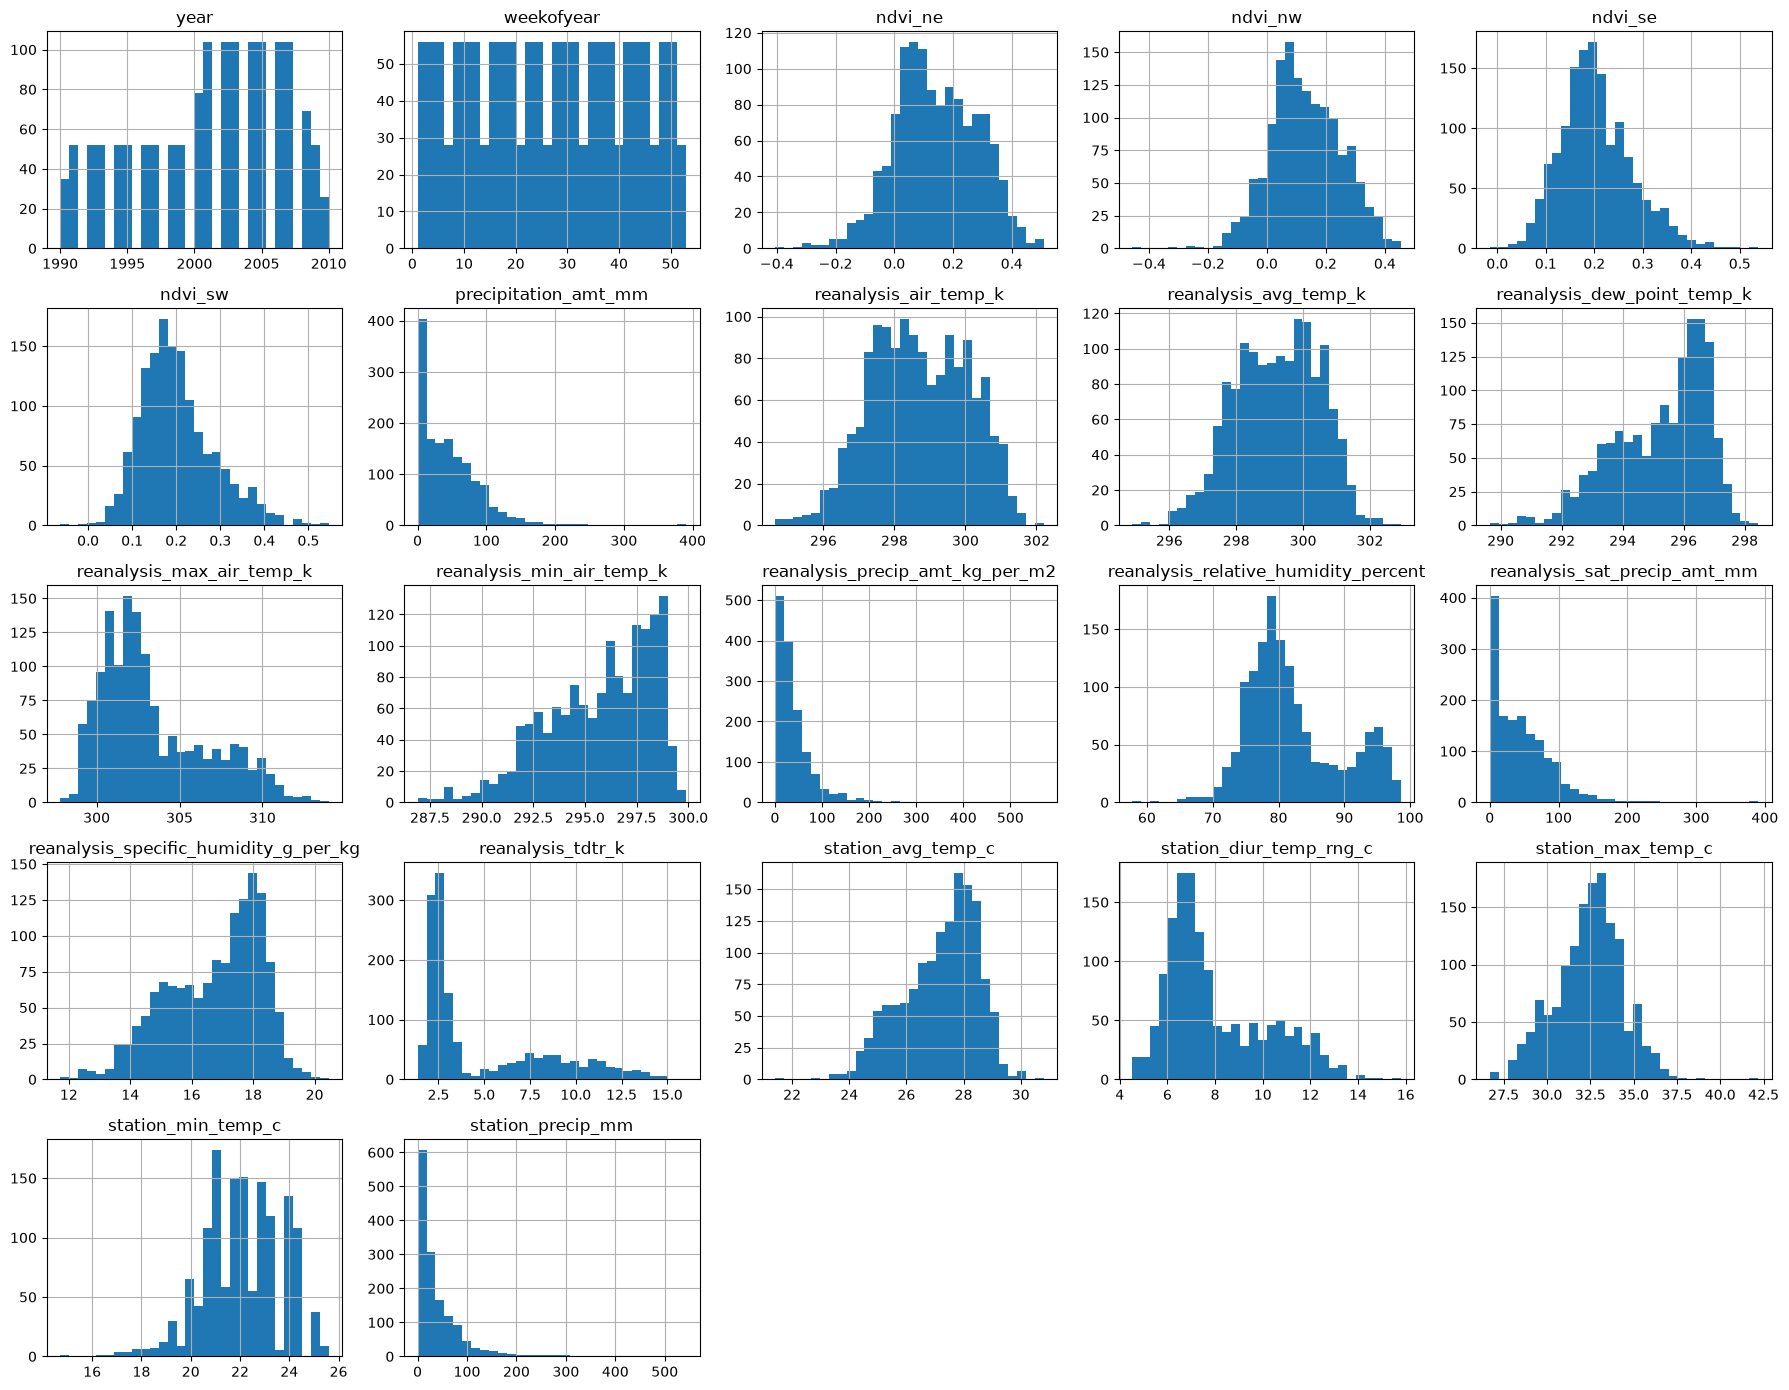

In [20]:
import matplotlib.pyplot as plt
features_train.hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

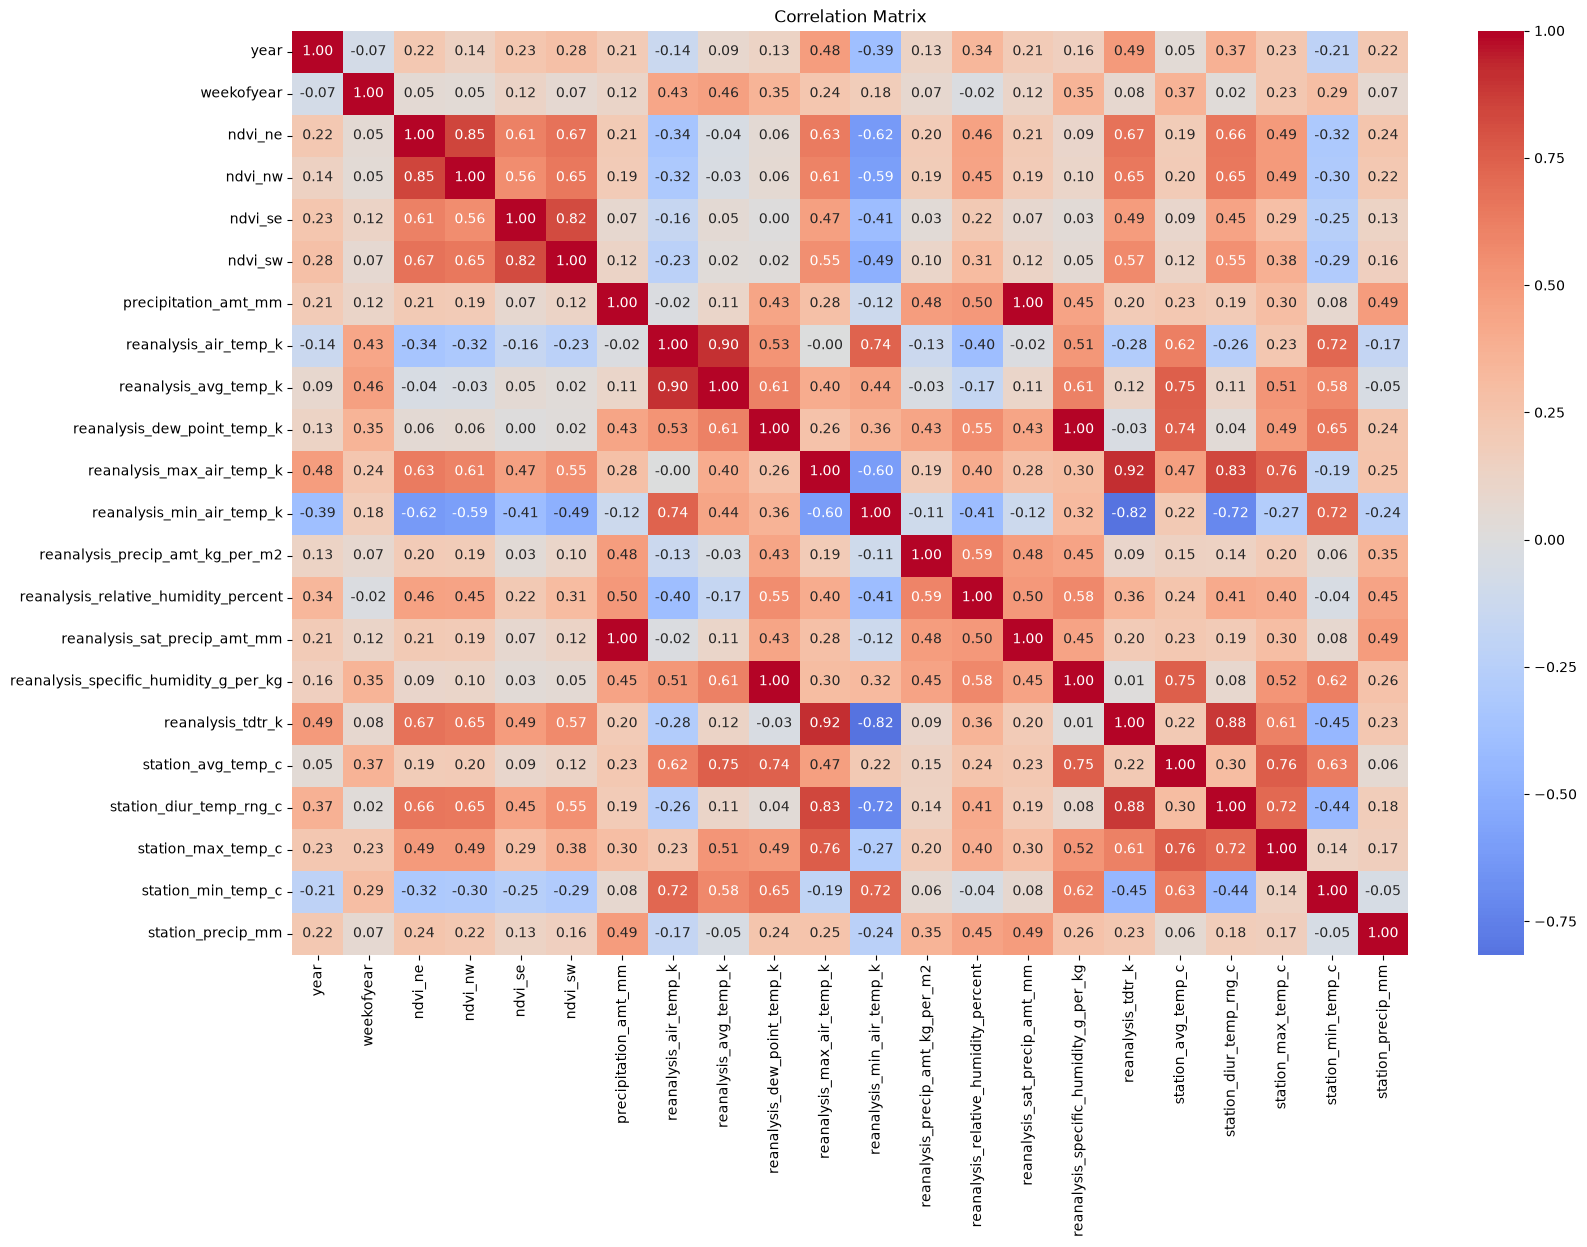

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))

corr = features_train.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [22]:
train_df = features_train.merge(
    labels_train,
    on=["city", "year", "weekofyear"]
)

train_df.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


In [23]:
train_df.shape

(1456, 25)

In [24]:
correlation_with_target = (
    train_df.select_dtypes(include="number")
    .corr()["total_cases"]
    .sort_values(ascending=False)
)

correlation_with_target

total_cases                              1.000000
reanalysis_min_air_temp_k                0.325252
station_min_temp_c                       0.267109
reanalysis_air_temp_k                    0.264952
weekofyear                               0.216452
reanalysis_avg_temp_k                    0.151637
reanalysis_dew_point_temp_k              0.142531
reanalysis_specific_humidity_g_per_kg    0.129861
station_avg_temp_c                       0.116109
reanalysis_precip_amt_kg_per_m2         -0.010031
reanalysis_sat_precip_amt_mm            -0.038740
precipitation_amt_mm                    -0.038740
station_max_temp_c                      -0.039219
station_precip_mm                       -0.074374
reanalysis_relative_humidity_percent    -0.132452
ndvi_se                                 -0.168612
reanalysis_max_air_temp_k               -0.191345
ndvi_sw                                 -0.196461
ndvi_nw                                 -0.202235
station_diur_temp_rng_c                 -0.237844


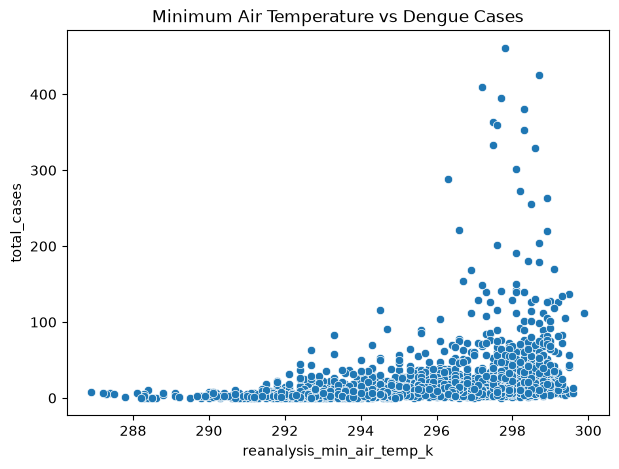

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=train_df,
    x="reanalysis_min_air_temp_k",
    y="total_cases"
)

plt.title("Minimum Air Temperature vs Dengue Cases")
plt.show()

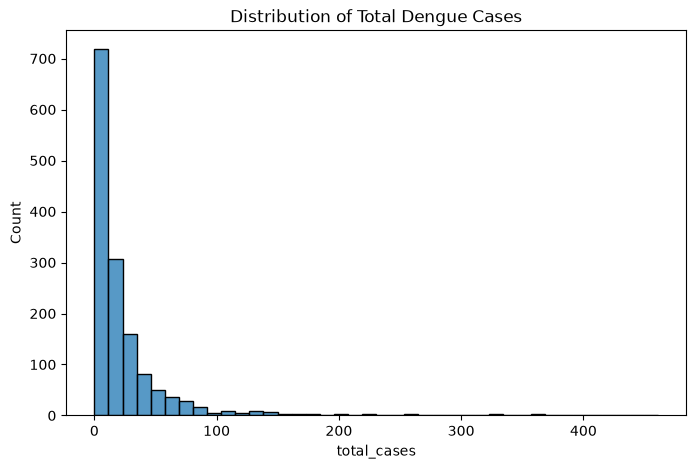

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["total_cases"], bins=40)

plt.title("Distribution of Total Dengue Cases")

plt.show()

In [27]:
train_df["city"].value_counts()

city
sj    936
iq    520
Name: count, dtype: int64

In [28]:
train_df.groupby("city")["total_cases"].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
iq,520.0,7.565385,10.765478,0.0,1.0,5.0,9.0,116.0
sj,936.0,34.180556,51.381372,0.0,9.0,19.0,37.0,461.0


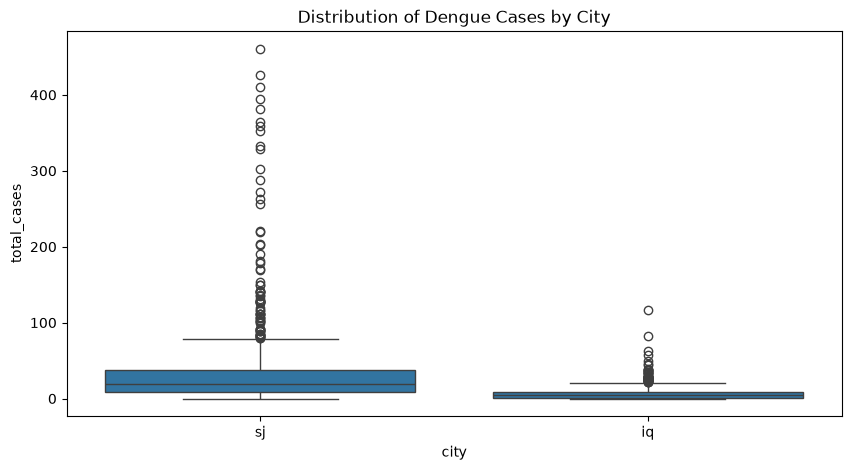

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=train_df,
    x="city",
    y="total_cases"
)

plt.title("Distribution of Dengue Cases by City")

plt.show()

In [30]:
train_df.groupby("city").mean(numeric_only=True).T

city,iq,sj
year,2005.000000,1998.826923
weekofyear,26.503846,26.503205
ndvi_ne,0.263869,0.057925
ndvi_nw,0.238783,0.067469
ndvi_se,0.250126,0.177655
ndvi_sw,0.266779,0.165956
precipitation_amt_mm,64.245736,35.470809
reanalysis_air_temp_k,297.869538,299.163653
reanalysis_avg_temp_k,299.133043,299.276920
reanalysis_dew_point_temp_k,295.492982,295.109519


In [31]:
sj = train_df[train_df["city"] == "sj"].copy()
iq = train_df[train_df["city"] == "iq"].copy()

print("SJ Shape:", sj.shape)
print("IQ Shape:", iq.shape)

SJ Shape: (936, 25)
IQ Shape: (520, 25)


In [32]:
sj_corr = (
    sj.corr(numeric_only=True)["total_cases"]
    .sort_values(ascending=False)
)

sj_corr

total_cases                              1.000000
weekofyear                               0.287134
reanalysis_specific_humidity_g_per_kg    0.207947
reanalysis_dew_point_temp_k              0.203774
station_avg_temp_c                       0.196617
reanalysis_max_air_temp_k                0.194532
station_max_temp_c                       0.189901
reanalysis_min_air_temp_k                0.187943
reanalysis_air_temp_k                    0.181917
station_min_temp_c                       0.177012
reanalysis_avg_temp_k                    0.175267
reanalysis_relative_humidity_percent     0.144045
reanalysis_precip_amt_kg_per_m2          0.107457
ndvi_nw                                  0.075307
precipitation_amt_mm                     0.060211
reanalysis_sat_precip_amt_mm             0.060211
station_precip_mm                        0.051759
ndvi_ne                                  0.037639
station_diur_temp_rng_c                  0.034630
ndvi_se                                  0.001113


In [33]:
iq_corr = (
    iq.corr(numeric_only=True)["total_cases"]
    .sort_values(ascending=False)
)

iq_corr

total_cases                              1.000000
reanalysis_specific_humidity_g_per_kg    0.236476
reanalysis_dew_point_temp_k              0.230401
reanalysis_min_air_temp_k                0.214514
station_min_temp_c                       0.211702
year                                     0.179451
reanalysis_relative_humidity_percent     0.130083
station_avg_temp_c                       0.113070
reanalysis_precip_amt_kg_per_m2          0.101171
reanalysis_air_temp_k                    0.097098
reanalysis_sat_precip_amt_mm             0.090171
precipitation_amt_mm                     0.090171
reanalysis_avg_temp_k                    0.079872
station_max_temp_c                       0.075279
station_precip_mm                        0.042976
ndvi_sw                                  0.032999
ndvi_ne                                  0.020215
ndvi_nw                                 -0.009586
weekofyear                              -0.011850
ndvi_se                                 -0.041067


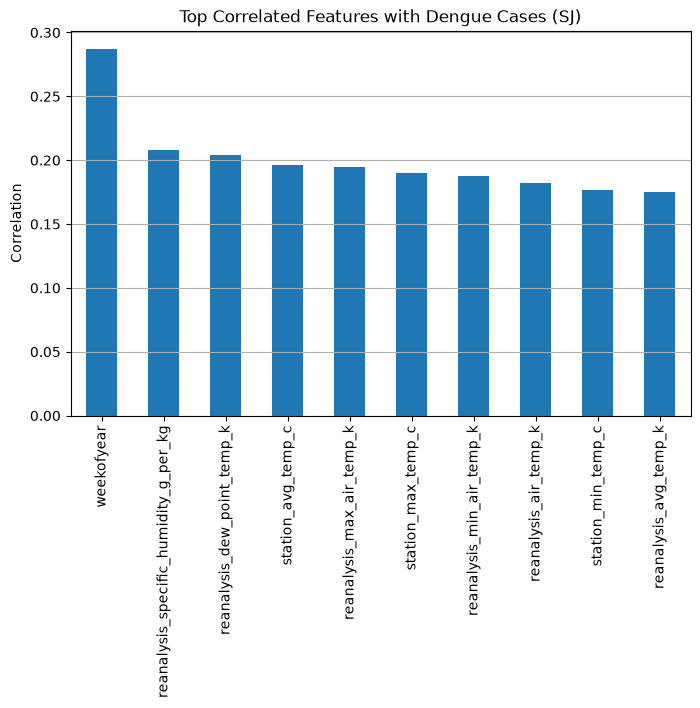

In [34]:
plt.figure(figsize=(8,5))

sj_corr.drop("total_cases").head(10).plot(kind="bar")

plt.title("Top Correlated Features with Dengue Cases (SJ)")
plt.ylabel("Correlation")
plt.grid(axis="y")

plt.show()

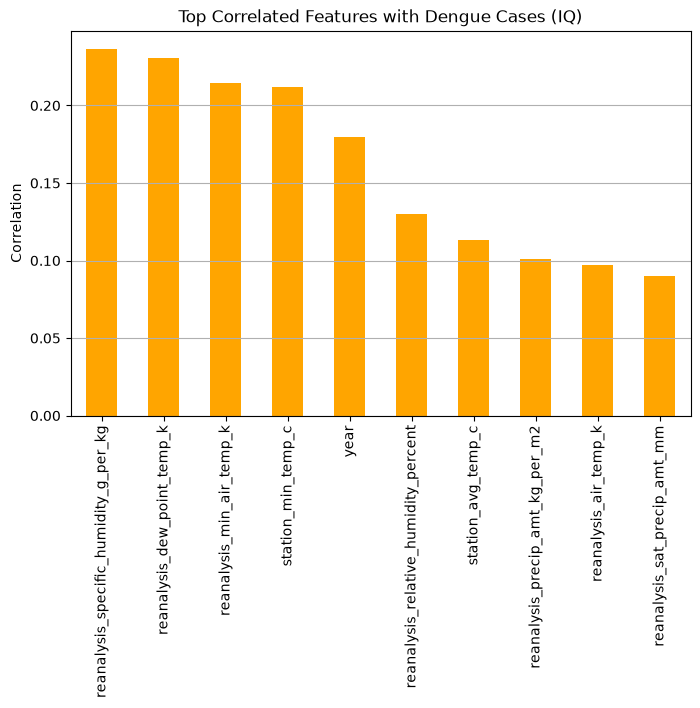

In [35]:
plt.figure(figsize=(8,5))

iq_corr.drop("total_cases").head(10).plot(kind="bar", color="orange")

plt.title("Top Correlated Features with Dengue Cases (IQ)")
plt.ylabel("Correlation")
plt.grid(axis="y")

plt.show()

In [36]:
sj["week_start_date"] = pd.to_datetime(sj["week_start_date"])
iq["week_start_date"] = pd.to_datetime(iq["week_start_date"])

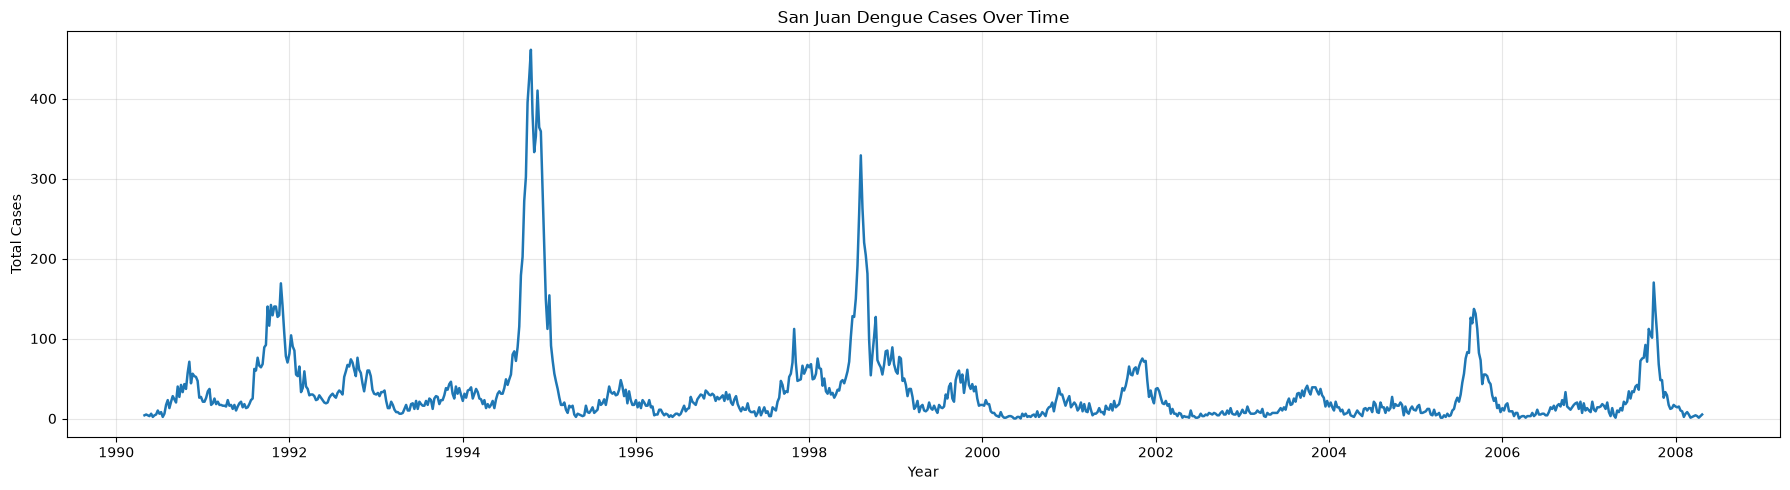

In [37]:
plt.figure(figsize=(18,5))

plt.plot(
    sj["week_start_date"],
    sj["total_cases"],
    linewidth=1.8
)

plt.title("San Juan Dengue Cases Over Time")

plt.xlabel("Year")

plt.ylabel("Total Cases")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

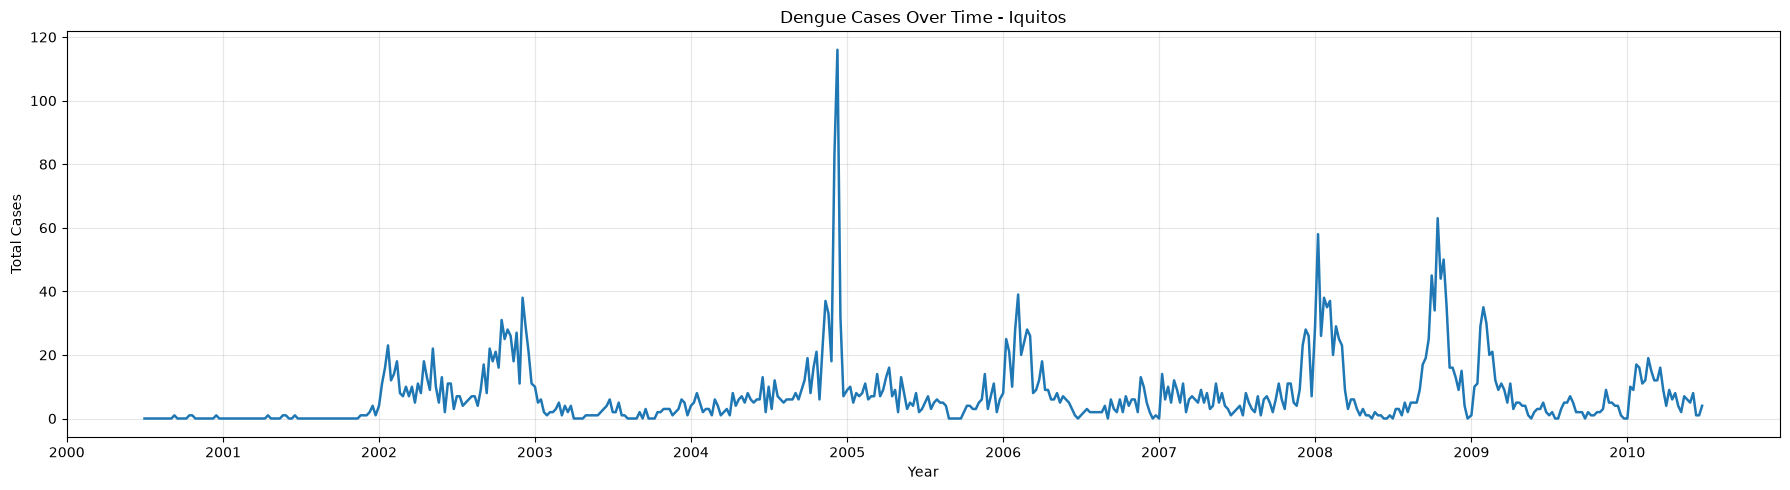

In [38]:
plt.figure(figsize=(18,5))

plt.plot(
    iq["week_start_date"],
    iq["total_cases"],
    linewidth=1.8
)

plt.title("Dengue Cases Over Time - Iquitos")

plt.xlabel("Year")

plt.ylabel("Total Cases")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [39]:
print("Duplicate Rows:", train_df.duplicated().sum())

Duplicate Rows: 0


In [40]:
train_df.duplicated(
    subset=["city", "year", "weekofyear"]
).sum()

np.int64(0)


<h2 style="
    color:#C2185B;
    font-size:26px;
    font-weight:700;
    border-left:5px solid #7B1FA2;
    padding-left:12px;
">
    outliers
</h2>

### precipitation_amt_mm

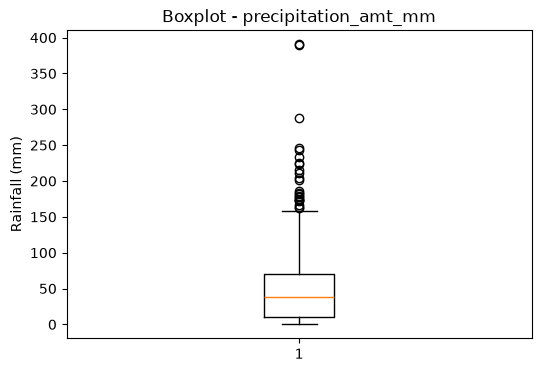

In [41]:
plt.figure(figsize=(6,4))

plt.boxplot(features_train["precipitation_amt_mm"].dropna())

plt.title("Boxplot - precipitation_amt_mm")

plt.ylabel("Rainfall (mm)")

plt.show()

### Rainfall Feature Analysis

The rainfall distribution is highly right-skewed.
Several statistical outliers are present.
These observations are considered realistic extreme weather events rather than data errors.
Therefore, rainfall outliers will be retained for model training.

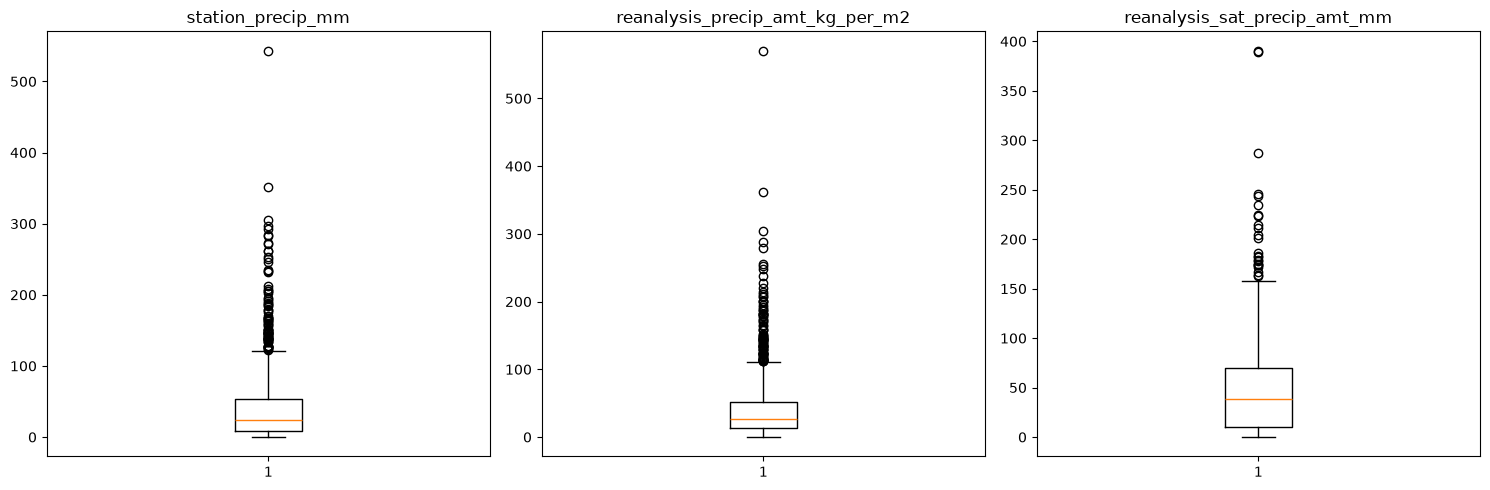

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].boxplot(features_train["station_precip_mm"].dropna())
axes[0].set_title("station_precip_mm")

axes[1].boxplot(features_train["reanalysis_precip_amt_kg_per_m2"].dropna())
axes[1].set_title("reanalysis_precip_amt_kg_per_m2")

axes[2].boxplot(features_train["reanalysis_sat_precip_amt_mm"].dropna())
axes[2].set_title("reanalysis_sat_precip_amt_mm")

plt.tight_layout()
plt.show()

In [43]:
features_train[
    ["precipitation_amt_mm", "reanalysis_sat_precip_amt_mm"]
].corr()

,precipitation_amt_mm,reanalysis_sat_precip_amt_mm
precipitation_amt_mm,1.0,1.0
reanalysis_sat_precip_amt_mm,1.0,1.0



<h2 style="
    color:#C2185B;
    font-size:26px;
    font-weight:700;
    border-left:5px solid #7B1FA2;
    padding-left:12px;
">
     Decision Log #1 — Rain Features
</h2>


### ✅ Findings
Rainfall features are highly right-skewed.
Heavy rainfall events appear to be genuine observations.
No evidence suggests rainfall outliers are data errors.
precipitation_amt_mm and reanalysis_sat_precip_amt_mm are perfectly identical (Correlation = 1.0).
### ✅ Decisions
Keep rainfall outliers.
Mark reanalysis_sat_precip_amt_mm as a candidate for removal during preprocessing.

In [44]:
temp_features = [
    "reanalysis_air_temp_k",
    "reanalysis_avg_temp_k",
    "reanalysis_max_air_temp_k",
    "reanalysis_min_air_temp_k",
    "reanalysis_dew_point_temp_k",
    "station_avg_temp_c",
    "station_max_temp_c",
    "station_min_temp_c",
    "station_diur_temp_rng_c"
]

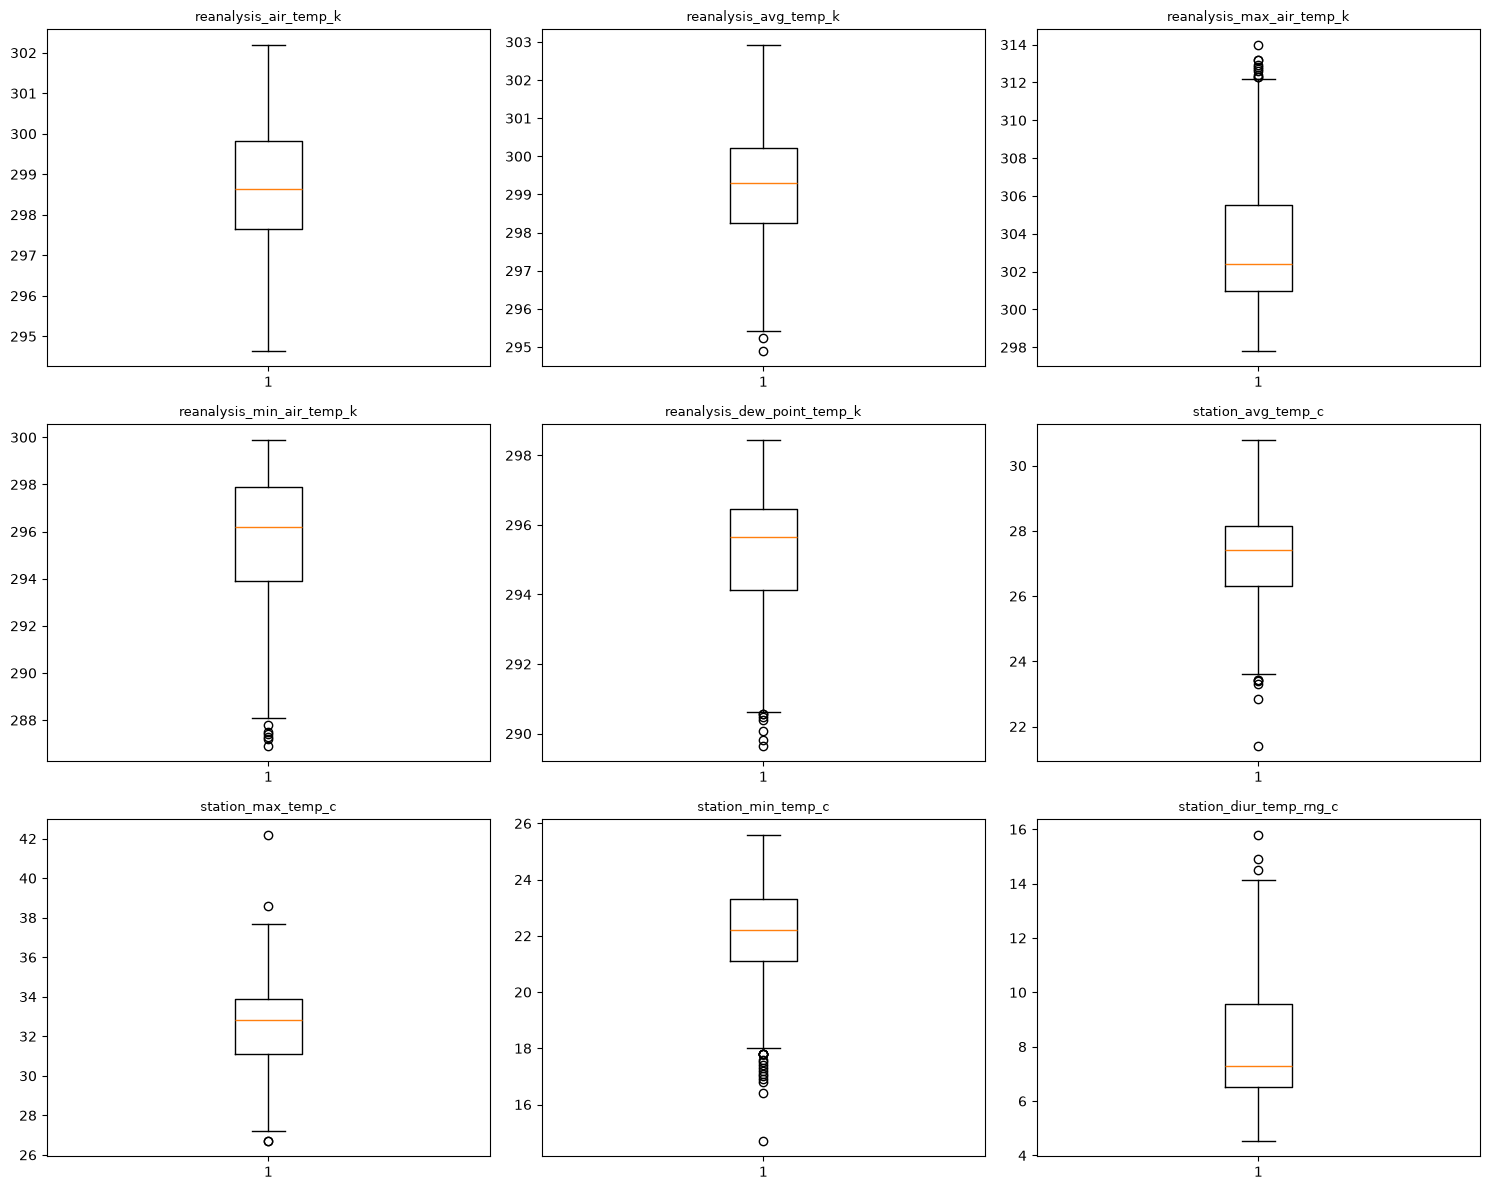

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), temp_features):
    ax.boxplot(features_train[col].dropna())
    ax.set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

## Temperature Features

Visualized using Boxplots.
Outliers were inspected manually.
Extreme values correspond to realistic weather conditions.
No evidence of sensor errors or impossible temperatures.
Therefore no outlier removal was applied.

In [46]:
humidity_features = [
    "reanalysis_relative_humidity_percent",
    "reanalysis_specific_humidity_g_per_kg",
    "reanalysis_tdtr_k"
]

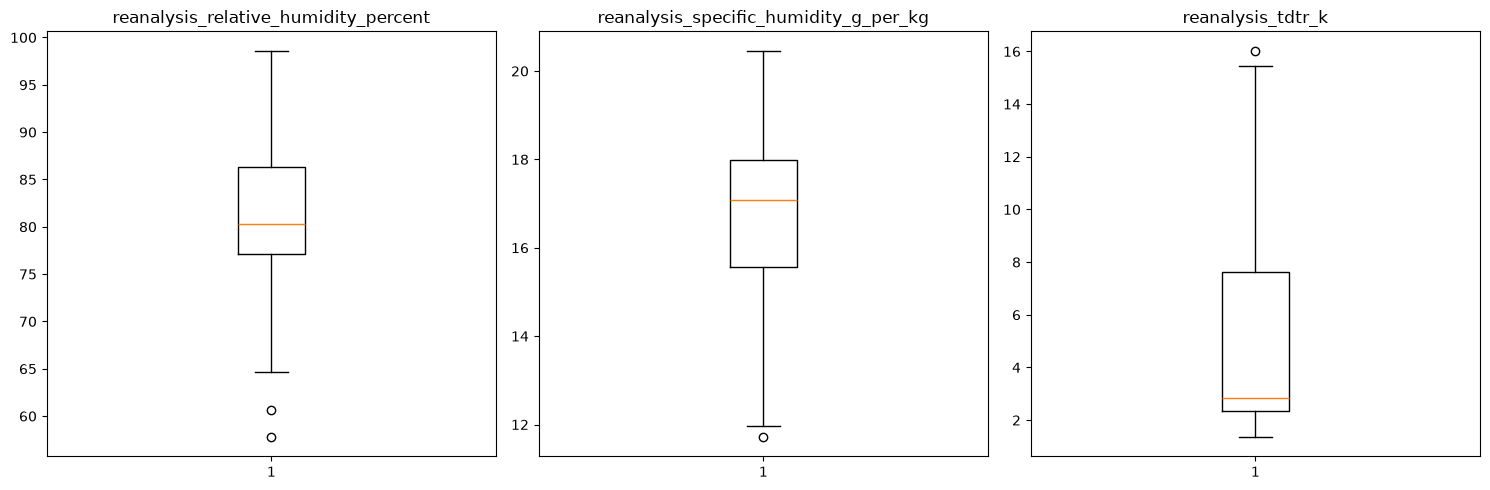

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, humidity_features):
    ax.boxplot(features_train[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

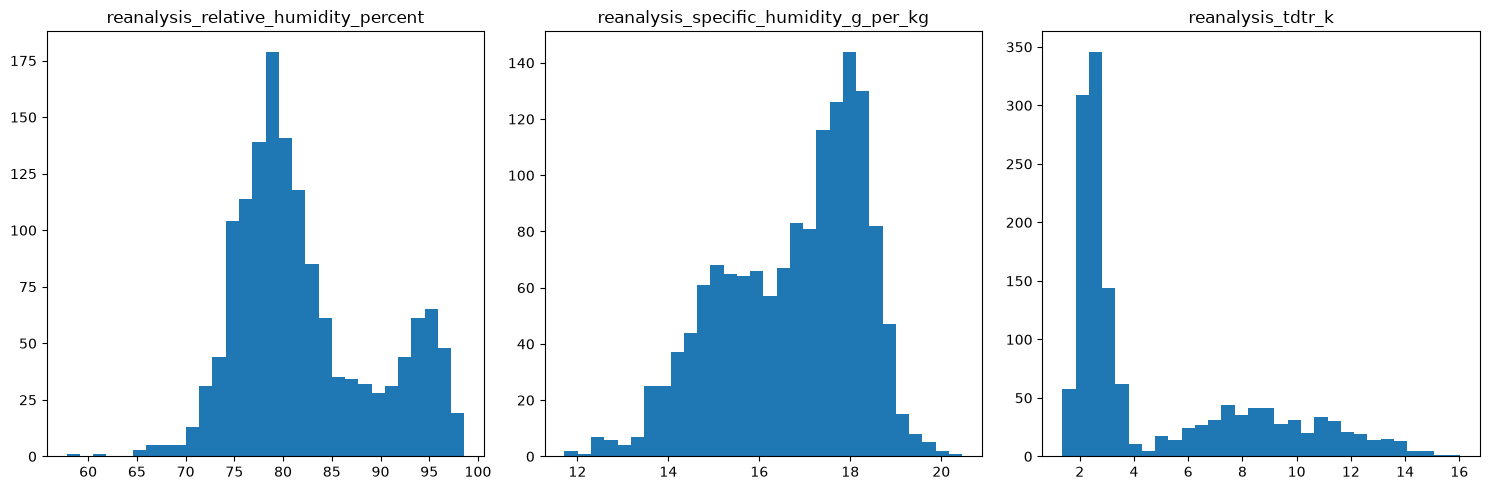

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, humidity_features):
    ax.hist(features_train[col].dropna(), bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()

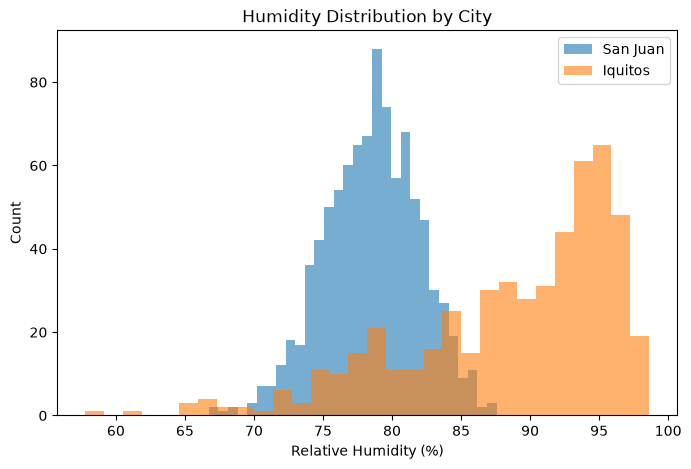

In [49]:
plt.figure(figsize=(8,5))

plt.hist(
    sj["reanalysis_relative_humidity_percent"],
    bins=30,
    alpha=0.6,
    label="San Juan"
)

plt.hist(
    iq["reanalysis_relative_humidity_percent"],
    bins=30,
    alpha=0.6,
    label="Iquitos"
)

plt.xlabel("Relative Humidity (%)")
plt.ylabel("Count")
plt.title("Humidity Distribution by City")
plt.legend()

plt.show()

<h2 style="
    color:#C2185B;
    font-size:26px;
    font-weight:700;
    border-left:5px solid #7B1FA2;
    padding-left:12px;
">
    Decision Log #3
</h2>


### Findings
Relative humidity follows different distributions across cities.
San Juan humidity is concentrated around 75–82%.
Iquitos humidity is concentrated around 90–97%.
The bimodal histogram observed earlier is caused by mixing two different cities, not by data quality issues.
Humidity outliers are physically plausible.
### Decisions
✅ Keep humidity features.
✅ Do not remove humidity outliers.
✅ Continue analyzing each city separately when appropriate.

In [50]:
ndvi_cols = [
    "ndvi_ne",
    "ndvi_nw",
    "ndvi_se",
    "ndvi_sw"
]

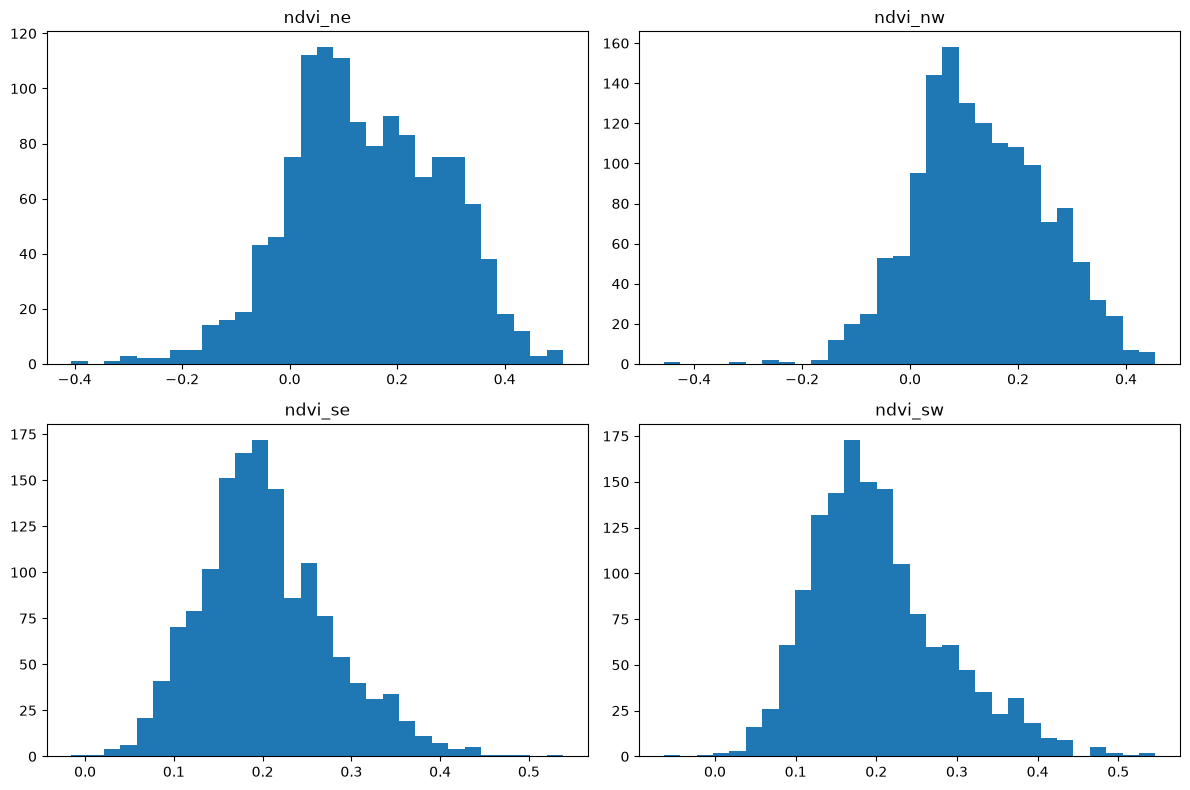

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, col in zip(axes.ravel(), ndvi_cols):
    ax.hist(train_df[col].dropna(), bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()

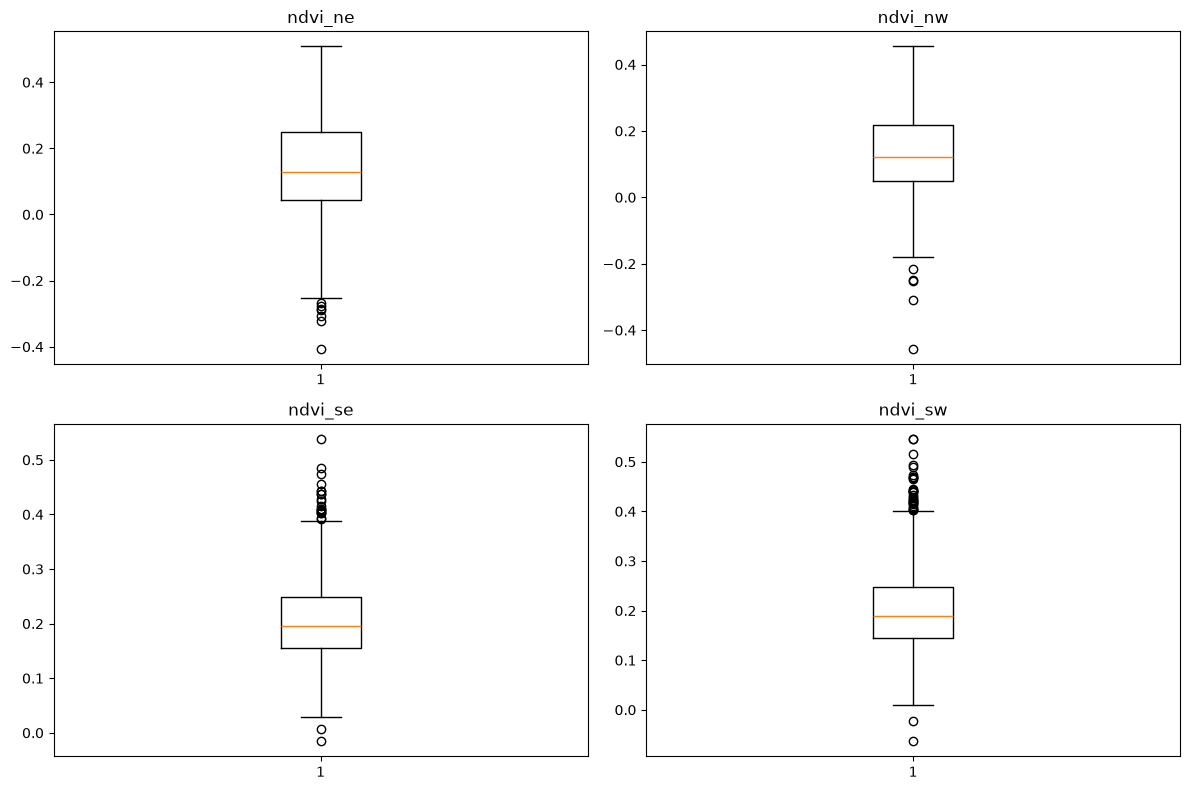

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, col in zip(axes.ravel(), ndvi_cols):
    ax.boxplot(train_df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [53]:
train_df[ndvi_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ndvi_ne,1262.0,0.142294,0.140531,-0.406250,0.044950,0.128817,0.248483,0.508357
ndvi_nw,1404.0,0.130553,0.119999,-0.456100,0.049217,0.121429,0.216600,0.454429
ndvi_se,1434.0,0.203783,0.073860,-0.015533,0.155087,0.196050,0.248846,0.538314
ndvi_sw,1434.0,0.202305,0.083903,-0.063457,0.144209,0.189450,0.246982,0.546017


In [54]:
for col in ndvi_cols:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]

    print(f"{col}")
    print(f"Outliers = {len(outliers)}")
    print("-"*40)

ndvi_ne
Outliers = 7
----------------------------------------
ndvi_nw
Outliers = 5
----------------------------------------
ndvi_se
Outliers = 22
----------------------------------------
ndvi_sw
Outliers = 33
----------------------------------------


### Outlier Analysis Summary

We analyzed outliers using boxplots and the IQR method.

The detected outliers were carefully inspected feature by feature.

Results:

- Rainfall features: retained.
- Temperature features: retained.
- Humidity features: retained.
- NDVI features: retained.

Reason:

The detected values represent natural environmental and climatic variations rather than measurement errors.

Therefore, no outliers were removed from the dataset.

In [55]:
missing = train_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

ndvi_ne                                  194
ndvi_nw                                   52
station_avg_temp_c                        43
station_diur_temp_rng_c                   43
ndvi_sw                                   22
ndvi_se                                   22
station_precip_mm                         22
station_max_temp_c                        20
station_min_temp_c                        14
precipitation_amt_mm                      13
reanalysis_sat_precip_amt_mm              13
reanalysis_air_temp_k                     10
reanalysis_relative_humidity_percent      10
reanalysis_precip_amt_kg_per_m2           10
reanalysis_min_air_temp_k                 10
reanalysis_max_air_temp_k                 10
reanalysis_dew_point_temp_k               10
reanalysis_avg_temp_k                     10
reanalysis_tdtr_k                         10
reanalysis_specific_humidity_g_per_kg     10
dtype: int64

In [56]:
missing_percent = (train_df.isnull().mean()*100)

missing_percent = missing_percent[missing_percent>0].sort_values(ascending=False)

missing_percent

ndvi_ne                                  13.324176
ndvi_nw                                   3.571429
station_avg_temp_c                        2.953297
station_diur_temp_rng_c                   2.953297
ndvi_sw                                   1.510989
ndvi_se                                   1.510989
station_precip_mm                         1.510989
station_max_temp_c                        1.373626
station_min_temp_c                        0.961538
precipitation_amt_mm                      0.892857
reanalysis_sat_precip_amt_mm              0.892857
reanalysis_air_temp_k                     0.686813
reanalysis_relative_humidity_percent      0.686813
reanalysis_precip_amt_kg_per_m2           0.686813
reanalysis_min_air_temp_k                 0.686813
reanalysis_max_air_temp_k                 0.686813
reanalysis_dew_point_temp_k               0.686813
reanalysis_avg_temp_k                     0.686813
reanalysis_tdtr_k                         0.686813
reanalysis_specific_humidity_g_

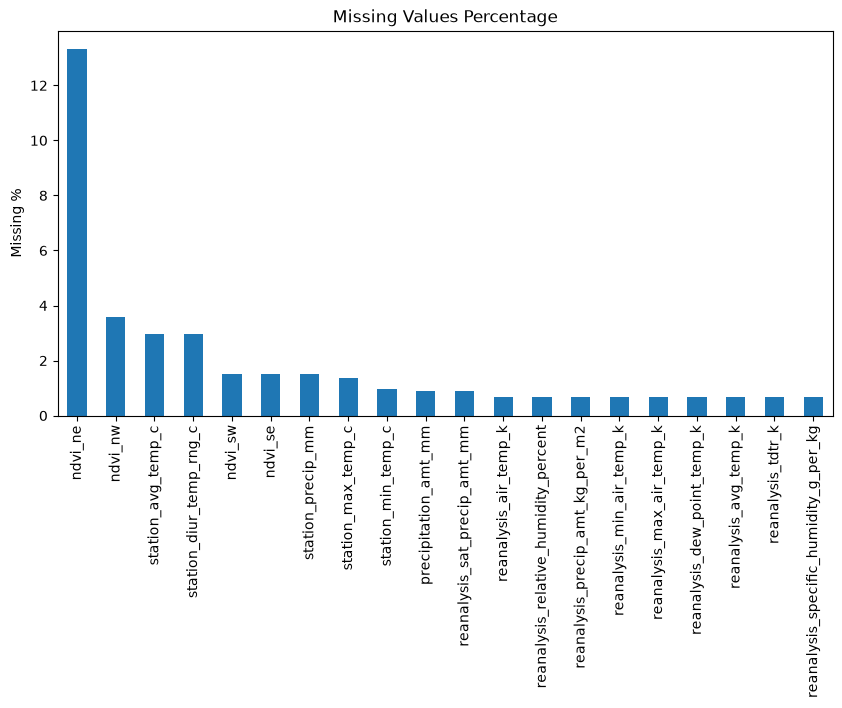

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

missing_percent.plot(kind="bar")

plt.ylabel("Missing %")
plt.title("Missing Values Percentage")

plt.show()

In [58]:
train_df.groupby("city").apply(
    lambda x: x.isnull().sum()
).T

city,iq,sj
year,0,0
weekofyear,0,0
week_start_date,0,0
ndvi_ne,3,191
ndvi_nw,3,49
ndvi_se,3,19
ndvi_sw,3,19
precipitation_amt_mm,4,9
reanalysis_air_temp_k,4,6
reanalysis_avg_temp_k,4,6


In [59]:
train_df[train_df.isnull().any(axis=1)]

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
5,sj,1990,23,1990-06-04,NaN,0.174850,0.254314,0.181743,9.58,299.630000,...,79.891429,9.58,17.212857,2.100000,28.114286,6.942857,34.4,23.9,39.1,2
9,sj,1990,27,1990-07-02,NaN,0.121550,0.160683,0.202567,14.41,300.154286,...,81.281429,14.41,18.071429,2.014286,28.328571,6.514286,33.9,24.4,1.1,6
13,sj,1990,31,1990-07-30,NaN,0.247150,0.379700,0.381357,32.66,299.862857,...,80.584286,32.66,17.594286,2.585714,28.242857,8.085714,34.4,22.8,37.6,17
14,sj,1990,32,1990-08-06,NaN,0.064333,0.164443,0.138857,28.80,300.391429,...,79.650000,28.80,17.950000,2.328571,28.200000,7.557143,33.3,23.3,11.4,23
15,sj,1990,33,1990-08-13,NaN,0.128033,0.206957,0.168243,90.75,299.958571,...,84.178571,90.75,18.515714,1.857143,28.042857,6.685714,32.8,22.8,44.7,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1400,iq,2009,23,2009-06-04,0.114000,0.092443,0.097471,0.126286,42.22,296.125714,...,95.507143,42.22,16.757143,6.071429,28.100000,11.800000,34.0,22.2,NaN,3
1409,iq,2009,32,2009-08-06,0.395000,0.352733,0.484286,0.401914,9.79,297.370000,...,87.811429,9.79,16.337143,11.757143,27.975000,12.100000,35.4,20.5,NaN,5
1430,iq,2010,53,2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1431,iq,2010,1,2010-01-08,0.124571,0.179129,0.163843,0.135471,27.04,299.264286,...,78.271429,27.04,16.127143,11.100000,28.600000,12.300000,35.1,21.8,NaN,10


In [60]:
train_df[train_df.isnull().any(axis=1)].head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
5,sj,1990,23,1990-06-04,NaN,0.174850,0.254314,0.181743,9.58,299.630000,...,79.891429,9.58,17.212857,2.100000,28.114286,6.942857,34.4,23.9,39.1,2
9,sj,1990,27,1990-07-02,NaN,0.121550,0.160683,0.202567,14.41,300.154286,...,81.281429,14.41,18.071429,2.014286,28.328571,6.514286,33.9,24.4,1.1,6
13,sj,1990,31,1990-07-30,NaN,0.247150,0.379700,0.381357,32.66,299.862857,...,80.584286,32.66,17.594286,2.585714,28.242857,8.085714,34.4,22.8,37.6,17
14,sj,1990,32,1990-08-06,NaN,0.064333,0.164443,0.138857,28.80,300.391429,...,79.650000,28.80,17.950000,2.328571,28.200000,7.557143,33.3,23.3,11.4,23
15,sj,1990,33,1990-08-13,NaN,0.128033,0.206957,0.168243,90.75,299.958571,...,84.178571,90.75,18.515714,1.857143,28.042857,6.685714,32.8,22.8,44.7,13




<h2 style="
    color:#C2185B;
    font-size:26px;
    font-weight:700;
    border-left:5px solid #7B1FA2;
    padding-left:12px;
">
    cleaning
</h2>

In [61]:
df_clean = train_df.copy()

numeric_cols = df_clean.select_dtypes(include="number").columns

for col in numeric_cols:
    if col != "total_cases":
        df_clean[col] = (
            df_clean
            .groupby("city")[col]
            .transform(lambda x: x.fillna(x.median()))
        )

In [62]:
df_clean.isnull().sum().sort_values(ascending=False)

city                                     0
year                                     0
weekofyear                               0
week_start_date                          0
ndvi_ne                                  0
ndvi_nw                                  0
ndvi_se                                  0
ndvi_sw                                  0
precipitation_amt_mm                     0
reanalysis_air_temp_k                    0
reanalysis_avg_temp_k                    0
reanalysis_dew_point_temp_k              0
reanalysis_max_air_temp_k                0
reanalysis_min_air_temp_k                0
reanalysis_precip_amt_kg_per_m2          0
reanalysis_relative_humidity_percent     0
reanalysis_sat_precip_amt_mm             0
reanalysis_specific_humidity_g_per_kg    0
reanalysis_tdtr_k                        0
station_avg_temp_c                       0
station_diur_temp_rng_c                  0
station_max_temp_c                       0
station_min_temp_c                       0
station_pre

<h1 style="
    background: linear-gradient(135deg, #4A148C, #7B1FA2, #E91E63);
    color: #FFFFFF;
    padding: 24px;
    border-radius: 18px;
    text-align: center;
    font-size: 34px;
    font-weight: 700;
    box-shadow: 0 8px 25px rgba(74, 20, 140, 0.35);
    letter-spacing: 1.2px;
    border: 1px solid rgba(255,255,255,0.15);
">
    Feature Engineering
</h1>




#### Removing Duplicate Features

precipitation_amt_mm   هنحتفظ ب دي
reanalysis_sat_precip_amt_mmهنمسح دي   

In [63]:
train_df = train_df.drop(columns=["reanalysis_sat_precip_amt_mm"])

In [64]:
"reanalysis_sat_precip_amt_mm" in train_df.columns

False

In [65]:
train_df.columns

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases'],
      dtype='str')

Correlation analysis showed that reanalysis_sat_precip_amt_mm was perfectly correlated (r = 1.00) with precipitation_amt_mm, indicating duplicated information. Therefore, it was removed to reduce redundancy and multicollinearity.

<h2 style="
    color:#7B1FA2;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #E91E63;
    padding-left:14px;
">
   Temporal Features
</h2>


In [66]:
train_df["week_start_date"] = pd.to_datetime(train_df["week_start_date"])

In [67]:
train_df["week_start_date"].head()

0   1990-04-30
1   1990-05-07
2   1990-05-14
3   1990-05-21
4   1990-05-28
Name: week_start_date, dtype: datetime64[us]

In [68]:
train_df["week_start_date"].dtype

dtype('<M8[us]')

In [69]:
train_df["month"] = train_df["week_start_date"].dt.month

In [70]:
train_df.groupby("month")["total_cases"].mean()

month
1     24.514286
2     18.053571
3     11.973214
4      8.478571
5      8.892857
6     11.696429
7     18.678571
8     32.008929
9     37.932773
10    49.353383
11    43.250000
12    31.401786
Name: total_cases, dtype: float64

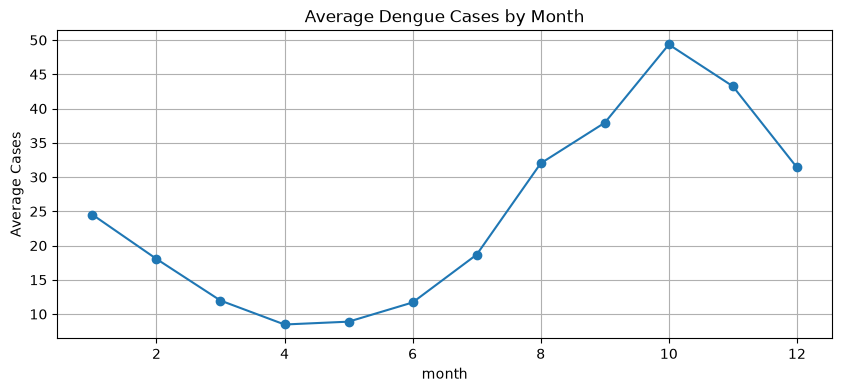

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

train_df.groupby("month")["total_cases"].mean().plot(marker="o")

plt.title("Average Dengue Cases by Month")
plt.ylabel("Average Cases")
plt.grid(True)

plt.show()

### Extract month from the date to capture seasonal patterns in dengue cases.

In [72]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

train_df["season"] = train_df["month"].apply(get_season)

In [73]:
train_df[["month", "season"]].head(10)

,month,season
0,4,Spring
1,5,Spring
2,5,Spring
3,5,Spring
4,5,Spring
5,6,Summer
6,6,Summer
7,6,Summer
8,6,Summer
9,7,Summer


In [74]:
train_df.groupby("season")["total_cases"].mean().sort_values()

season
Spring     9.681319
Summer    20.631868
Winter    24.645604
Autumn    43.741758
Name: total_cases, dtype: float64

In [75]:
train_df.drop(columns="season", inplace=True)

### Temporal Feature Engineering

The `week_start_date` column was converted to a datetime format to enable extracting time-based features.

#### Month
A new `month` feature was created because dengue transmission is strongly influenced by seasonal weather conditions. Exploratory analysis showed clear differences in the average number of dengue cases across different months, making it a valuable predictive feature.

#### Season
A `season` feature was also tested. However, since the `month` feature provides more detailed information than broad seasonal categories, the `season` feature was removed to avoid losing useful temporal information.

#### Quarter
A `quarter` feature was not created because it groups multiple months together, reducing the temporal resolution of the data.


<h2 style="
    color:#7B1FA2;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #E91E63;
    padding-left:14px;
">
   NDVI Features
</h2>

In [76]:
train_df["ndvi_mean"] = train_df[
    ["ndvi_ne", "ndvi_nw", "ndvi_se", "ndvi_sw"]
].mean(axis=1)

In [77]:
train_df[[
    "ndvi_ne",
    "ndvi_nw",
    "ndvi_se",
    "ndvi_sw",
    "ndvi_mean"
]].head()

,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,ndvi_mean
0,0.122600,0.103725,0.198483,0.177617,0.150606
1,0.169900,0.142175,0.162357,0.155486,0.157479
2,0.032250,0.172967,0.157200,0.170843,0.133315
3,0.128633,0.245067,0.227557,0.235886,0.209286
4,0.196200,0.262200,0.251200,0.247340,0.239235


In [78]:
train_df["ndvi_mean"].corr(train_df["total_cases"])

np.float64(-0.22506265336836637)

##### Create the average NDVI value across the four regions
#### to represent the overall vegetation level surrounding the city.

In [79]:
train_df["ndvi_mean"].corr(train_df["total_cases"])

np.float64(-0.22506265336836637)

### # Create the average NDVI across the four geographical regions.
#### This feature represents the overall vegetation level around the city.
#### The original NDVI features are retained because each region may contain
#### unique spatial information useful for prediction.

In [80]:
train_df["ndvi_range"] = (
    train_df[["ndvi_ne", "ndvi_nw", "ndvi_se", "ndvi_sw"]].max(axis=1)
    -
    train_df[["ndvi_ne", "ndvi_nw", "ndvi_se", "ndvi_sw"]].min(axis=1)
)

In [81]:
train_df["ndvi_range"].corr(train_df["total_cases"])

np.float64(0.0658024643687217)

In [82]:
train_df.drop(columns="ndvi_range", inplace=True)


<h2 style="
    color:#7B1FA2;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #E91E63;
    padding-left:14px;
">
    Weather Feature Engineering
</h2>

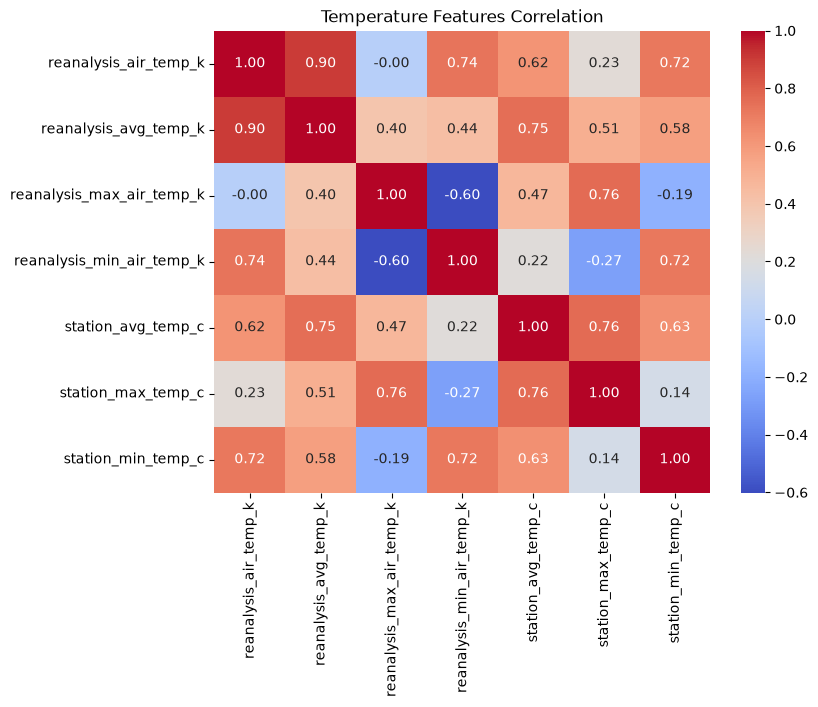

In [83]:
temp_cols = [
    "reanalysis_air_temp_k",
    "reanalysis_avg_temp_k",
    "reanalysis_max_air_temp_k",
    "reanalysis_min_air_temp_k",
    "station_avg_temp_c",
    "station_max_temp_c",
    "station_min_temp_c"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    train_df[temp_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Temperature Features Correlation")

plt.show()

In [84]:
train_df["temp_range"] = (
    train_df["reanalysis_max_air_temp_k"]
    - train_df["reanalysis_min_air_temp_k"]
)

train_df["temp_range"].head()

0    3.9
1    4.5
2    3.2
3    4.4
4    4.4
Name: temp_range, dtype: float64

In [85]:
train_df["temp_range"].corr(train_df["total_cases"])

np.float64(-0.2796109137810685)

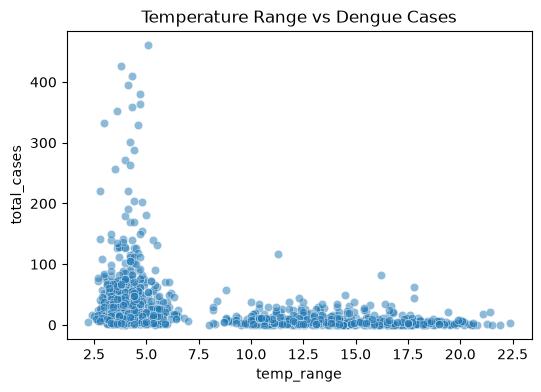

In [86]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=train_df ,
    x="temp_range",
    y="total_cases",
    alpha=0.5
)

plt.title("Temperature Range vs Dengue Cases")
plt.show()

### Observation

We created Temperature Range as the difference between
maximum and minimum reanalysis temperature.

The feature shows a moderate negative correlation
(-0.28) with dengue cases.

This suggests that weeks with more stable temperatures
tend to have higher dengue incidence.

The feature will be retained for model training.

#############################

### Temperature Difference

In [87]:
train_df["temp_diff"] = (
    train_df["station_avg_temp_c"]
    - (train_df ["reanalysis_avg_temp_k"] - 273.15)
)

In [88]:
train_df["temp_diff"].head()

0    0.850000
1    1.421429
2    0.985714
3    1.392857
4    2.428571
Name: temp_diff, dtype: float64

In [89]:
train_df["temp_diff"].corr(train_df["total_cases"])

np.float64(-0.042539303230094326)

In [90]:
train_df.drop(columns="temp_diff", inplace=True)

Observation

A new feature (temp_diff) was created as the difference
between station average temperature and reanalysis average temperature.

After evaluating its relationship with the target,
the correlation was approximately -0.04,
indicating almost no predictive value.

Therefore, this feature was removed from the dataset.

## Feature Engineering

The following new features were created during feature engineering:

### Temporal Features
- `month` → Extracted from `week_start_date`
- `season` → Derived from `month`

### Vegetation Features
- `ndvi_mean` → Average of all NDVI measurements (`ndvi_ne`, `ndvi_nw`, `ndvi_se`, `ndvi_sw`)

### Temperature Features
- `temp_range` → Difference between `reanalysis_max_air_temp_k` and `reanalysis_min_air_temp_k`

### Removed Features
- `temp_diff` → Created as the difference between station and reanalysis average temperatures, but removed due to very weak correlation with the target.


<h2 style="
    color:#1565C0;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #00ACC1;
    padding-left:14px;
">
    Preprocessing
</h2>

In [91]:
y = train_df["total_cases"]

In [92]:
X = train_df.drop(columns=["total_cases"])

In [93]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1456, 26)
y shape: (1456,)


In [94]:
X.columns.tolist()

['city',
 'year',
 'weekofyear',
 'week_start_date',
 'ndvi_ne',
 'ndvi_nw',
 'ndvi_se',
 'ndvi_sw',
 'precipitation_amt_mm',
 'reanalysis_air_temp_k',
 'reanalysis_avg_temp_k',
 'reanalysis_dew_point_temp_k',
 'reanalysis_max_air_temp_k',
 'reanalysis_min_air_temp_k',
 'reanalysis_precip_amt_kg_per_m2',
 'reanalysis_relative_humidity_percent',
 'reanalysis_specific_humidity_g_per_kg',
 'reanalysis_tdtr_k',
 'station_avg_temp_c',
 'station_diur_temp_rng_c',
 'station_max_temp_c',
 'station_min_temp_c',
 'station_precip_mm',
 'month',
 'ndvi_mean',
 'temp_range']

In [95]:
X = X.drop(columns=["week_start_date"])

In [96]:
# Split the dataset by city

sj_train = train_df[train_df["city"] == "sj"].copy()
iq_train = train_df[train_df["city"] == "iq"].copy()

In [97]:
print("SJ Shape :", sj_train.shape)
print("IQ Shape :", iq_train.shape)

SJ Shape : (936, 27)
IQ Shape : (520, 27)


In [98]:
drop_cols = ["city", "week_start_date"]

sj_train.drop(columns=drop_cols, inplace=True)
iq_train.drop(columns=drop_cols, inplace=True)

In [99]:
sj_train.head()

,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,month,ndvi_mean,temp_range
0,1990,18,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,...,2.628571,25.442857,6.900000,29.4,20.0,16.0,4,4,0.150606,3.9
1,1990,19,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,...,2.371429,26.714286,6.371429,31.7,22.2,8.6,5,5,0.157479,4.5
2,1990,20,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,...,2.300000,26.714286,6.485714,32.2,22.8,41.4,4,5,0.133315,3.2
3,1990,21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,...,2.428571,27.471429,6.771429,33.3,23.3,4.0,3,5,0.209286,4.4
4,1990,22,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,...,3.014286,28.942857,9.371429,35.0,23.9,5.8,6,5,0.239235,4.4


In [100]:
# San Juan

X_sj = sj_train.drop(columns=["total_cases"])
y_sj = sj_train["total_cases"]


# Iquitos

X_iq = iq_train.drop(columns=["total_cases"])
y_iq = iq_train["total_cases"]

In [101]:
print(X_sj.shape, y_sj.shape)
print(X_iq.shape, y_iq.shape)

(936, 24) (936,)
(520, 24) (520,)


In [102]:
sj_train = sj_train.sort_values(["year", "weekofyear"]).reset_index(drop=True)
iq_train = iq_train.sort_values(["year", "weekofyear"]).reset_index(drop=True)

In [103]:
split_sj = int(len(sj_train) * 0.8)

train_sj = sj_train.iloc[:split_sj]
valid_sj = sj_train.iloc[split_sj:]

In [104]:
split_iq = int(len(iq_train) * 0.8)

train_iq = iq_train.iloc[:split_iq]
valid_iq = iq_train.iloc[split_iq:]

In [105]:
print(train_sj.shape)
print(valid_sj.shape)

print(train_iq.shape)
print(valid_iq.shape)

(748, 25)
(188, 25)
(416, 25)
(104, 25)


In [106]:
X_train_sj = train_sj.drop(columns=["total_cases"])
y_train_sj = train_sj["total_cases"]

X_valid_sj = valid_sj.drop(columns=["total_cases"])
y_valid_sj = valid_sj["total_cases"]

In [107]:
X_train_iq = train_iq.drop(columns=["total_cases"])
y_train_iq = train_iq["total_cases"]

X_valid_iq = valid_iq.drop(columns=["total_cases"])
y_valid_iq = valid_iq["total_cases"]

In [108]:
print(X_train_sj.shape, y_train_sj.shape)
print(X_valid_sj.shape, y_valid_sj.shape)

print(X_train_iq.shape, y_train_iq.shape)
print(X_valid_iq.shape, y_valid_iq.shape)

(748, 24) (748,)
(188, 24) (188,)
(416, 24) (416,)
(104, 24) (104,)


In [109]:
print("San Juan:")
print(X_train_sj.index.min(), X_train_sj.index.max())
print(X_valid_sj.index.min(), X_valid_sj.index.max())

print("\nIquitos:")
print(X_train_iq.index.min(), X_train_iq.index.max())
print(X_valid_iq.index.min(), X_valid_iq.index.max())

San Juan:
0 747
748 935

Iquitos:
0 415
416 519


<h1 style="
    background: linear-gradient(135deg, #4A148C, #7B1FA2, #E91E63);
    color: #FFFFFF;
    padding: 24px;
    border-radius: 18px;
    text-align: center;
    font-size: 34px;
    font-weight: 700;
    box-shadow: 0 8px 25px rgba(74, 20, 140, 0.35);
    letter-spacing: 1.2px;
    border: 1px solid rgba(255,255,255,0.15);
">
    Model Training & Comparison
</h1>

In [110]:
categorical_features = ["city"]

numeric_features = [
    col for col in X_train_sj.columns
    if col not in categorical_features
]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)
print("Number of numeric features:", len(numeric_features))

Categorical: ['city']
Numeric: ['year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm', 'month', 'ndvi_mean', 'temp_range']
Number of numeric features: 24



<h2 style="
    color:#E65100;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #FFB300;
    padding-left:14px;
">
    Linear Regression
</h2>

### Scaling

In [111]:
from sklearn.preprocessing import StandardScaler

scaler_sj = StandardScaler()
scaler_iq = StandardScaler()

X_train_sj_scaled = scaler_sj.fit_transform(X_train_sj)
X_valid_sj_scaled = scaler_sj.transform(X_valid_sj)

X_train_iq_scaled = scaler_iq.fit_transform(X_train_iq)
X_valid_iq_scaled = scaler_iq.transform(X_valid_iq)

print(X_train_sj_scaled.shape, X_valid_sj_scaled.shape)
print(X_train_iq_scaled.shape, X_valid_iq_scaled.shape)

(748, 24) (188, 24)
(416, 24) (104, 24)


### Model

In [112]:
X_train_sj = X_train_sj.ffill()
X_train_iq = X_train_iq.ffill()

X_valid_sj = X_valid_sj.ffill()
X_valid_iq = X_valid_iq.ffill()

In [113]:
print("San Juan:")
print(X_train_sj.isna().sum()[X_train_sj.isna().sum() > 0])

print("\nIquitos:")
print(X_train_iq.isna().sum()[X_train_iq.isna().sum() > 0])

San Juan:
Series([], dtype: int64)

Iquitos:
Series([], dtype: int64)


In [114]:
print("SJ NaN:", X_train_sj.isna().sum().sum())
print("IQ NaN:", X_train_iq.isna().sum().sum())

print("SJ Valid NaN:", X_valid_sj.isna().sum().sum())
print("IQ Valid NaN:", X_valid_iq.isna().sum().sum())

SJ NaN: 0
IQ NaN: 0
SJ Valid NaN: 1
IQ Valid NaN: 9


In [115]:
# Fill remaining missing values in validation
X_valid_sj = X_valid_sj.fillna(X_train_sj.iloc[-1])
X_valid_iq = X_valid_iq.fillna(X_train_iq.iloc[-1])

print("SJ Valid NaN:", X_valid_sj.isna().sum().sum())
print("IQ Valid NaN:", X_valid_iq.isna().sum().sum())

SJ Valid NaN: 0
IQ Valid NaN: 0


In [116]:
from sklearn.preprocessing import StandardScaler

scaler_sj = StandardScaler()
scaler_iq = StandardScaler()

X_train_sj_scaled = scaler_sj.fit_transform(X_train_sj)
X_valid_sj_scaled = scaler_sj.transform(X_valid_sj)

X_train_iq_scaled = scaler_iq.fit_transform(X_train_iq)
X_valid_iq_scaled = scaler_iq.transform(X_valid_iq)

print(X_train_sj_scaled.shape, X_valid_sj_scaled.shape)
print(X_train_iq_scaled.shape, X_valid_iq_scaled.shape)

(748, 24) (188, 24)
(416, 24) (104, 24)


In [117]:
from sklearn.linear_model import LinearRegression

lr_sj = LinearRegression()
lr_iq = LinearRegression()

lr_sj.fit(X_train_sj_scaled, y_train_sj)
lr_iq.fit(X_train_iq_scaled, y_train_iq)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


### predictions

In [118]:
# Predictions
y_pred_sj = lr_sj.predict(X_valid_sj_scaled)
y_pred_iq = lr_iq.predict(X_valid_iq_scaled)

print("San Juan:")
print(y_pred_sj[:5])

print("\nIquitos:")
print(y_pred_iq[:5])

San Juan:
[58.26549923 55.39884924  5.2288053  30.33414326 60.07353656]

Iquitos:
[ 6.76959915  4.11623064  6.46788469  9.13095409 10.37619067]


### Evaluation (MAE + RMSE + R²)

In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# San Juan
mae_sj = mean_absolute_error(y_valid_sj, y_pred_sj)
rmse_sj = np.sqrt(mean_squared_error(y_valid_sj, y_pred_sj))
r2_sj = r2_score(y_valid_sj, y_pred_sj)

# Iquitos
mae_iq = mean_absolute_error(y_valid_iq, y_pred_iq)
rmse_iq = np.sqrt(mean_squared_error(y_valid_iq, y_pred_iq))
r2_iq = r2_score(y_valid_iq, y_pred_iq)

print("San Juan")
print("MAE :", mae_sj)
print("RMSE:", rmse_sj)
print("R²  :", r2_sj)

print("\nIquitos")
print("MAE :", mae_iq)
print("RMSE:", rmse_iq)
print("R²  :", r2_iq)

San Juan
MAE : 24.112471841368826
RMSE: 33.834915412853164
R²  : -0.17805986007019547

Iquitos
MAE : 8.640870746771922
RMSE: 11.89001453438721
R²  : -0.08411562026694375


<h2 style="
    color:#E65100;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #FFB300;
    padding-left:14px;
">
     Ridge
</h2>

In [120]:
from sklearn.linear_model import Ridge

ridge_sj = Ridge(alpha=1.0)
ridge_iq = Ridge(alpha=1.0)

ridge_sj.fit(X_train_sj_scaled, y_train_sj)
ridge_iq.fit(X_train_iq_scaled, y_train_iq)

ridge_pred_sj = ridge_sj.predict(X_valid_sj_scaled)
ridge_pred_iq = ridge_iq.predict(X_valid_iq_scaled)

print("San Juan predictions:", ridge_pred_sj[:5])
print("Iquitos predictions:", ridge_pred_iq[:5])

San Juan predictions: [59.02735839 55.83365804  7.17674462 28.54520804 57.41500487]
Iquitos predictions: [ 7.68148419  4.74470693  7.05593072  9.00572174 10.27801017]


In [121]:
# Ridge Evaluation

mae_ridge_sj = mean_absolute_error(y_valid_sj, ridge_pred_sj)
rmse_ridge_sj = np.sqrt(mean_squared_error(y_valid_sj, ridge_pred_sj))
r2_ridge_sj = r2_score(y_valid_sj, ridge_pred_sj)

mae_ridge_iq = mean_absolute_error(y_valid_iq, ridge_pred_iq)
rmse_ridge_iq = np.sqrt(mean_squared_error(y_valid_iq, ridge_pred_iq))
r2_ridge_iq = r2_score(y_valid_iq, ridge_pred_iq)

print("San Juan")
print("MAE :", mae_ridge_sj)
print("RMSE:", rmse_ridge_sj)
print("R²  :", r2_ridge_sj)

print("\nIquitos")
print("MAE :", mae_ridge_iq)
print("RMSE:", rmse_ridge_iq)
print("R²  :", r2_ridge_iq)

San Juan
MAE : 23.982143851686523
RMSE: 33.7847329160319
R²  : -0.1745679556967925

Iquitos
MAE : 8.624008351181512
RMSE: 11.858775189292935
R²  : -0.07842638054250406



<h2 style="
    color:#E65100;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #FFB300;
    padding-left:14px;
">
    Random Forest Regressor
</h2>

In [122]:
from sklearn.ensemble import RandomForestRegressor

rf_sj = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_iq = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_sj.fit(X_train_sj, y_train_sj)
rf_iq.fit(X_train_iq, y_train_iq)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [123]:
# Random Forest Predictions

rf_pred_sj = rf_sj.predict(X_valid_sj)
rf_pred_iq = rf_iq.predict(X_valid_iq)

print("San Juan:", rf_pred_sj[:5])
print("Iquitos:", rf_pred_iq[:5])

San Juan: [51.73       29.79       25.36333333 37.19       31.00333333]
Iquitos: [1.59       2.05       1.99666667 2.39       3.42333333]


In [124]:
# Random Forest Evaluation

mae_rf_sj = mean_absolute_error(y_valid_sj, rf_pred_sj)
rmse_rf_sj = np.sqrt(mean_squared_error(y_valid_sj, rf_pred_sj))
r2_rf_sj = r2_score(y_valid_sj, rf_pred_sj)

mae_rf_iq = mean_absolute_error(y_valid_iq, rf_pred_iq)
rmse_rf_iq = np.sqrt(mean_squared_error(y_valid_iq, rf_pred_iq))
r2_rf_iq = r2_score(y_valid_iq, rf_pred_iq)

print("San Juan")
print("MAE :", mae_rf_sj)
print("RMSE:", rmse_rf_sj)
print("R²  :", r2_rf_sj)

print("\nIquitos")
print("MAE :", mae_rf_iq)
print("RMSE:", rmse_rf_iq)
print("R²  :", r2_rf_iq)

San Juan
MAE : 17.94035460992908
RMSE: 30.488594929969835
R²  : 0.0434405004290902

Iquitos
MAE : 7.70852564102564
RMSE: 12.344791532928088
R²  : -0.1686335539415642



<h2 style="
    color:#E65100;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #FFB300;
    padding-left:14px;
">
    Gradient Boosting
</h2>

In [125]:
from sklearn.ensemble import GradientBoostingRegressor

gb_sj = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_iq = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_sj.fit(X_train_sj, y_train_sj)
gb_iq.fit(X_train_iq, y_train_iq)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================
# Predictions
# =========================

gb_pred_sj = gb_sj.predict(X_valid_sj)
gb_pred_iq = gb_iq.predict(X_valid_iq)

print("San Juan predictions:", gb_pred_sj[:5])
print("Iquitos predictions:", gb_pred_iq[:5])


# =========================
# Evaluation
# =========================

# San Juan
gb_mae_sj = mean_absolute_error(y_valid_sj, gb_pred_sj)
gb_rmse_sj = np.sqrt(mean_squared_error(y_valid_sj, gb_pred_sj))
gb_r2_sj = r2_score(y_valid_sj, gb_pred_sj)

# Iquitos
gb_mae_iq = mean_absolute_error(y_valid_iq, gb_pred_iq)
gb_rmse_iq = np.sqrt(mean_squared_error(y_valid_iq, gb_pred_iq))
gb_r2_iq = r2_score(y_valid_iq, gb_pred_iq)


# =========================
# Results
# =========================

print("\nGradient Boosting Results")

print(
    f"San Juan MAE : {gb_mae_sj:.4f}",
    f"RMSE: {gb_rmse_sj:.4f}",
    f"R²  : {gb_r2_sj:.4f}"
)

print(
    f"Iquitos MAE : {gb_mae_iq:.4f}",
    f"RMSE: {gb_rmse_iq:.4f}",
    f"R²  : {gb_r2_iq:.4f}"
)

San Juan predictions: [56.37309163 29.69158964 19.73802856 31.42908734 44.14753692]
Iquitos predictions: [1.9847897  1.36505372 3.26657477 3.65954094 5.04332869]

Gradient Boosting Results
San Juan MAE : 17.4576 RMSE: 29.7814 R²  : 0.0873
Iquitos MAE : 7.0657 RMSE: 12.1347 R²  : -0.1292



<h2 style="
    color:#E65100;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #FFB300;
    padding-left:14px;
">
    HistGradientBoosting
</h2>

In [127]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_sj = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

hgb_iq = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

hgb_sj.fit(X_train_sj, y_train_sj)
hgb_iq.fit(X_train_iq, y_train_iq)

print("HistGradientBoosting trained successfully!")

HistGradientBoosting trained successfully!


In [128]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
hgb_pred_sj = hgb_sj.predict(X_valid_sj)
hgb_pred_iq = hgb_iq.predict(X_valid_iq)

print("San Juan predictions:", hgb_pred_sj[:5])
print("Iquitos predictions:", hgb_pred_iq[:5])


# Evaluation - San Juan
hgb_mae_sj = mean_absolute_error(y_valid_sj, hgb_pred_sj)
hgb_rmse_sj = np.sqrt(mean_squared_error(y_valid_sj, hgb_pred_sj))
hgb_r2_sj = r2_score(y_valid_sj, hgb_pred_sj)

# Evaluation - Iquitos
hgb_mae_iq = mean_absolute_error(y_valid_iq, hgb_pred_iq)
hgb_rmse_iq = np.sqrt(mean_squared_error(y_valid_iq, hgb_pred_iq))
hgb_r2_iq = r2_score(y_valid_iq, hgb_pred_iq)


print("\nHistGradientBoosting Results")

print(
    f"San Juan MAE : {hgb_mae_sj:.4f} "
    f"RMSE: {hgb_rmse_sj:.4f} "
    f"R²  : {hgb_r2_sj:.4f}"
)

print(
    f"Iquitos MAE : {hgb_mae_iq:.4f} "
    f"RMSE: {hgb_rmse_iq:.4f} "
    f"R²  : {hgb_r2_iq:.4f}"
)

San Juan predictions: [160.49548204  38.67551922  16.21317561  39.07538911  45.42728319]
Iquitos predictions: [5.10593906 3.95843715 4.0754595  5.00252729 8.5891724 ]

HistGradientBoosting Results
San Juan MAE : 19.6051 RMSE: 32.4832 R²  : -0.0858
Iquitos MAE : 8.0006 RMSE: 11.7788 R²  : -0.0639


<h2 style="
    color:#E65100;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #FFB300;
    padding-left:14px;
">
     xgboost
</h2>

In [129]:
from xgboost import XGBRegressor

xgb_sj = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_iq = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_sj.fit(X_train_sj, y_train_sj)
xgb_iq.fit(X_train_iq, y_train_iq)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [130]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
xgb_pred_sj = xgb_sj.predict(X_valid_sj)
xgb_pred_iq = xgb_iq.predict(X_valid_iq)

print("San Juan predictions:", xgb_pred_sj[:5])
print("Iquitos predictions:", xgb_pred_iq[:5])


# San Juan metrics
xgb_mae_sj = mean_absolute_error(y_valid_sj, xgb_pred_sj)
xgb_rmse_sj = np.sqrt(mean_squared_error(y_valid_sj, xgb_pred_sj))
xgb_r2_sj = r2_score(y_valid_sj, xgb_pred_sj)

# Iquitos metrics
xgb_mae_iq = mean_absolute_error(y_valid_iq, xgb_pred_iq)
xgb_rmse_iq = np.sqrt(mean_squared_error(y_valid_iq, xgb_pred_iq))
xgb_r2_iq = r2_score(y_valid_iq, xgb_pred_iq)


print("\nXGBoost Results")

print("San Juan MAE :", round(xgb_mae_sj, 4))
print("San Juan RMSE:", round(xgb_rmse_sj, 4))
print("San Juan R²  :", round(xgb_r2_sj, 4))

print("\nIquitos MAE :", round(xgb_mae_iq, 4))
print("Iquitos RMSE:", round(xgb_rmse_iq, 4))
print("Iquitos R²  :", round(xgb_r2_iq, 4))

San Juan predictions: [35.250015 29.539686 35.464027 41.72389  47.694866]
Iquitos predictions: [1.4075607 1.1625618 2.567292  3.1839397 4.529785 ]

XGBoost Results
San Juan MAE : 19.6898
San Juan RMSE: 34.605
San Juan R²  : -0.2323

Iquitos MAE : 7.2581
Iquitos RMSE: 12.2636
Iquitos R²  : -0.1533



<h2 style="
    color:#1565C0;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #00ACC1;
    padding-left:14px;
">
    lag --> target
</h2>

In [131]:
# ==========================================
# 1. Sort data chronologically
# ==========================================

sj_train = sj_train.sort_values(
    ["year", "weekofyear"]
).reset_index(drop=True)

iq_train = iq_train.sort_values(
    ["year", "weekofyear"]
).reset_index(drop=True)


# ==========================================
# 2. Create Lag Features
# ==========================================

for lag in [1, 2, 4, 12]:

    sj_train[f"cases_lag_{lag}"] = sj_train["total_cases"].shift(lag)

    iq_train[f"cases_lag_{lag}"] = iq_train["total_cases"].shift(lag)


# ==========================================
# 3. Check the new features
# ==========================================

print("San Juan:")
print(
    sj_train[
        ["year", "weekofyear", "total_cases",
         "cases_lag_1", "cases_lag_2",
         "cases_lag_4", "cases_lag_12"]
    ].head(15)
)

print("\nIquitos:")
print(
    iq_train[
        ["year", "weekofyear", "total_cases",
         "cases_lag_1", "cases_lag_2",
         "cases_lag_4", "cases_lag_12"]
    ].head(15)
)

San Juan:
    year  weekofyear  total_cases  cases_lag_1  cases_lag_2  cases_lag_4  \
0   1990          18            4          NaN          NaN          NaN   
1   1990          19            5          4.0          NaN          NaN   
2   1990          20            4          5.0          4.0          NaN   
3   1990          21            3          4.0          5.0          NaN   
4   1990          22            6          3.0          4.0          4.0   
5   1990          23            2          6.0          3.0          5.0   
6   1990          24            4          2.0          6.0          4.0   
7   1990          25            5          4.0          2.0          3.0   
8   1990          26           10          5.0          4.0          6.0   
9   1990          27            6         10.0          5.0          2.0   
10  1990          28            8          6.0         10.0          4.0   
11  1990          29            2          8.0          6.0          5.0   
12

In [132]:
# ==========================================
# Re-create chronological train/validation split
# ==========================================

split_sj = int(len(sj_train) * 0.8)
split_iq = int(len(iq_train) * 0.8)

train_sj = sj_train.iloc[:split_sj].copy()
valid_sj = sj_train.iloc[split_sj:].copy()

train_iq = iq_train.iloc[:split_iq].copy()
valid_iq = iq_train.iloc[split_iq:].copy()


print("San Juan:")
print("Train:", train_sj.shape)
print("Valid:", valid_sj.shape)

print("\nIquitos:")
print("Train:", train_iq.shape)
print("Valid:", valid_iq.shape)

San Juan:
Train: (748, 29)
Valid: (188, 29)

Iquitos:
Train: (416, 29)
Valid: (104, 29)


In [133]:
# ==========================================
# Prepare X and y
# ==========================================

X_train_sj = train_sj.drop(columns=["total_cases"])
y_train_sj = train_sj["total_cases"]

X_valid_sj = valid_sj.drop(columns=["total_cases"])
y_valid_sj = valid_sj["total_cases"]


X_train_iq = train_iq.drop(columns=["total_cases"])
y_train_iq = train_iq["total_cases"]

X_valid_iq = valid_iq.drop(columns=["total_cases"])
y_valid_iq = valid_iq["total_cases"]


# Check NaN
print("SJ Train NaN:", X_train_sj.isna().sum().sum())
print("SJ Valid NaN:", X_valid_sj.isna().sum().sum())

print("IQ Train NaN:", X_train_iq.isna().sum().sum())
print("IQ Valid NaN:", X_valid_iq.isna().sum().sum())

SJ Train NaN: 354
SJ Valid NaN: 61
IQ Train NaN: 138
IQ Valid NaN: 52


In [134]:
print("===== San Juan Train =====")
print(X_train_sj.isna().sum()[X_train_sj.isna().sum() > 0])

print("\n===== San Juan Valid =====")
print(X_valid_sj.isna().sum()[X_valid_sj.isna().sum() > 0])

print("\n===== Iquitos Train =====")
print(X_train_iq.isna().sum()[X_train_iq.isna().sum() > 0])

print("\n===== Iquitos Valid =====")
print(X_valid_iq.isna().sum()[X_valid_iq.isna().sum() > 0])

===== San Juan Train =====
ndvi_ne                                  156
ndvi_nw                                   42
ndvi_se                                   18
ndvi_sw                                   18
precipitation_amt_mm                       8
reanalysis_air_temp_k                      5
reanalysis_avg_temp_k                      5
reanalysis_dew_point_temp_k                5
reanalysis_max_air_temp_k                  5
reanalysis_min_air_temp_k                  5
reanalysis_precip_amt_kg_per_m2            5
reanalysis_relative_humidity_percent       5
reanalysis_specific_humidity_g_per_kg      5
reanalysis_tdtr_k                          5
station_avg_temp_c                         5
station_diur_temp_rng_c                    5
station_max_temp_c                         5
station_min_temp_c                         5
station_precip_mm                          5
ndvi_mean                                 18
temp_range                                 5
cases_lag_1                 

In [135]:
lag_cols = [
    "cases_lag_1",
    "cases_lag_2",
    "cases_lag_4",
    "cases_lag_12"
]

print("SJ lag NaN:")
print(X_train_sj[lag_cols].isna().sum())

print("\nIQ lag NaN:")
print(X_train_iq[lag_cols].isna().sum())

print("\nSJ Valid lag NaN:")
print(X_valid_sj[lag_cols].isna().sum())

print("\nIQ Valid lag NaN:")
print(X_valid_iq[lag_cols].isna().sum())

SJ lag NaN:
cases_lag_1      1
cases_lag_2      2
cases_lag_4      4
cases_lag_12    12
dtype: int64

IQ lag NaN:
cases_lag_1      1
cases_lag_2      2
cases_lag_4      4
cases_lag_12    12
dtype: int64

SJ Valid lag NaN:
cases_lag_1     0
cases_lag_2     0
cases_lag_4     0
cases_lag_12    0
dtype: int64

IQ Valid lag NaN:
cases_lag_1     0
cases_lag_2     0
cases_lag_4     0
cases_lag_12    0
dtype: int64


In [136]:
from sklearn.impute import SimpleImputer

# ==========================================
# 1. Remove rows with missing lag features
#    from TRAIN only
# ==========================================

train_sj_clean = train_sj.dropna(subset=lag_cols).copy()
train_iq_clean = train_iq.dropna(subset=lag_cols).copy()


# ==========================================
# 2. Prepare X and y
# ==========================================

X_train_sj = train_sj_clean.drop(columns=["total_cases"])
y_train_sj = train_sj_clean["total_cases"]

X_valid_sj = valid_sj.drop(columns=["total_cases"])
y_valid_sj = valid_sj["total_cases"]


X_train_iq = train_iq_clean.drop(columns=["total_cases"])
y_train_iq = train_iq_clean["total_cases"]

X_valid_iq = valid_iq.drop(columns=["total_cases"])
y_valid_iq = valid_iq["total_cases"]


# ==========================================
# 3. Median Imputation
#    FIT ONLY on training data
# ==========================================

imputer_sj = SimpleImputer(strategy="median")
imputer_iq = SimpleImputer(strategy="median")


X_train_sj = imputer_sj.fit_transform(X_train_sj)
X_valid_sj = imputer_sj.transform(X_valid_sj)

X_train_iq = imputer_iq.fit_transform(X_train_iq)
X_valid_iq = imputer_iq.transform(X_valid_iq)


# ==========================================
# 4. Check
# ==========================================

print("SJ Train shape:", X_train_sj.shape)
print("SJ Valid shape:", X_valid_sj.shape)

print("IQ Train shape:", X_train_iq.shape)
print("IQ Valid shape:", X_valid_iq.shape)



print("\nNaN check:")

print("SJ Train:", np.isnan(X_train_sj).sum())
print("SJ Valid:", np.isnan(X_valid_sj).sum())

print("IQ Train:", np.isnan(X_train_iq).sum())
print("IQ Valid:", np.isnan(X_valid_iq).sum())

SJ Train shape: (736, 28)
SJ Valid shape: (188, 28)
IQ Train shape: (404, 28)
IQ Valid shape: (104, 28)

NaN check:
SJ Train: 0
SJ Valid: 0
IQ Train: 0
IQ Valid: 0



<h2 style="
    color:#2E7D32;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #66BB6A;
    padding-left:14px;
">
    Random Forest + Lag Features
</h2>

In [137]:
from sklearn.ensemble import RandomForestRegressor

rf_sj_lag = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_iq_lag = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_sj_lag.fit(X_train_sj, y_train_sj)
rf_iq_lag.fit(X_train_iq, y_train_iq)

print("Random Forest with Lag Features trained successfully!")

Random Forest with Lag Features trained successfully!


In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================
# Predictions
# =========================

rf_sj_lag_pred = rf_sj_lag.predict(X_valid_sj)
rf_iq_lag_pred = rf_iq_lag.predict(X_valid_iq)


# =========================
# Print sample predictions
# =========================

print("San Juan predictions:")
print(rf_sj_lag_pred[:5])

print("\nIquitos predictions:")
print(rf_iq_lag_pred[:5])


# =========================
# San Juan Metrics
# =========================

sj_mae = mean_absolute_error(y_valid_sj, rf_sj_lag_pred)
sj_rmse = np.sqrt(mean_squared_error(y_valid_sj, rf_sj_lag_pred))
sj_r2 = r2_score(y_valid_sj, rf_sj_lag_pred)


# =========================
# Iquitos Metrics
# =========================

iq_mae = mean_absolute_error(y_valid_iq, rf_iq_lag_pred)
iq_rmse = np.sqrt(mean_squared_error(y_valid_iq, rf_iq_lag_pred))
iq_r2 = r2_score(y_valid_iq, rf_iq_lag_pred)


# =========================
# Results
# =========================

print("\n===== Random Forest + Lag Features =====")

print(
    f"San Juan MAE : {sj_mae:.4f}\n"
    f"San Juan RMSE: {sj_rmse:.4f}\n"
    f"San Juan R²  : {sj_r2:.4f}"
)

print()

print(
    f"Iquitos MAE : {iq_mae:.4f}\n"
    f"Iquitos RMSE: {iq_rmse:.4f}\n"
    f"Iquitos R²  : {iq_r2:.4f}"
)

San Juan predictions:
[15.09       13.72       33.57333333 17.32333333 20.09666667]

Iquitos predictions:
[0.83333333 0.48       2.04666667 3.37333333 3.25333333]

===== Random Forest + Lag Features =====
San Juan MAE : 7.3211
San Juan RMSE: 11.0796
San Juan R²  : 0.8737

Iquitos MAE : 4.3499
Iquitos RMSE: 6.8189
Iquitos R²  : 0.6434



<h2 style="
    color:#2E7D32;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #66BB6A;
    padding-left:14px;
">
    Gradient Boosting + Lag Features
</h2>

In [139]:
from sklearn.ensemble import GradientBoostingRegressor

gb_sj_lag = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_iq_lag = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_sj_lag.fit(X_train_sj, y_train_sj)
gb_iq_lag.fit(X_train_iq, y_train_iq)

print("Gradient Boosting + Lag Features trained successfully!")

Gradient Boosting + Lag Features trained successfully!


In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
gb_sj_lag_pred = gb_sj_lag.predict(X_valid_sj)
gb_iq_lag_pred = gb_iq_lag.predict(X_valid_iq)

print("San Juan predictions:", gb_sj_lag_pred[:5])
print("Iquitos predictions:", gb_iq_lag_pred[:5])

# San Juan
sj_mae = mean_absolute_error(y_valid_sj, gb_sj_lag_pred)
sj_rmse = np.sqrt(mean_squared_error(y_valid_sj, gb_sj_lag_pred))
sj_r2 = r2_score(y_valid_sj, gb_sj_lag_pred)

# Iquitos
iq_mae = mean_absolute_error(y_valid_iq, gb_iq_lag_pred)
iq_rmse = np.sqrt(mean_squared_error(y_valid_iq, gb_iq_lag_pred))
iq_r2 = r2_score(y_valid_iq, gb_iq_lag_pred)

print("\n===== Gradient Boosting + Lag Features =====")

print(
    f"San Juan MAE : {sj_mae:.4f}\n"
    f"San Juan RMSE: {sj_rmse:.4f}\n"
    f"San Juan R²  : {sj_r2:.4f}"
)

print()

print(
    f"Iquitos MAE : {iq_mae:.4f}\n"
    f"Iquitos RMSE: {iq_rmse:.4f}\n"
    f"Iquitos R²  : {iq_r2:.4f}"
)

San Juan predictions: [14.2673863  10.31318931 27.80833525 17.14676277 17.5209597 ]
Iquitos predictions: [0.75793983 0.61614785 1.62459475 1.64543161 2.62407046]

===== Gradient Boosting + Lag Features =====
San Juan MAE : 7.4333
San Juan RMSE: 11.9053
San Juan R²  : 0.8541

Iquitos MAE : 4.5963
Iquitos RMSE: 7.4373
Iquitos R²  : 0.5758


<h2 style="
    color:#2E7D32;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #66BB6A;
    padding-left:14px;
">
     XGBoost + Lag Features
</h2>

In [141]:
from xgboost import XGBRegressor

xgb_sj_lag = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_iq_lag = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_sj_lag.fit(X_train_sj, y_train_sj)
xgb_iq_lag.fit(X_train_iq, y_train_iq)

print("XGBoost + Lag Features trained successfully!")

XGBoost + Lag Features trained successfully!


In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
xgb_sj_lag_pred = xgb_sj_lag.predict(X_valid_sj)
xgb_iq_lag_pred = xgb_iq_lag.predict(X_valid_iq)

print("San Juan predictions:", xgb_sj_lag_pred[:5])
print("Iquitos predictions:", xgb_iq_lag_pred[:5])

# San Juan
sj_mae = mean_absolute_error(y_valid_sj, xgb_sj_lag_pred)
sj_rmse = np.sqrt(mean_squared_error(y_valid_sj, xgb_sj_lag_pred))
sj_r2 = r2_score(y_valid_sj, xgb_sj_lag_pred)

# Iquitos
iq_mae = mean_absolute_error(y_valid_iq, xgb_iq_lag_pred)
iq_rmse = np.sqrt(mean_squared_error(y_valid_iq, xgb_iq_lag_pred))
iq_r2 = r2_score(y_valid_iq, xgb_iq_lag_pred)

print("\n===== XGBoost + Lag Features =====")

print(
    f"San Juan MAE : {sj_mae:.4f}\n"
    f"San Juan RMSE: {sj_rmse:.4f}\n"
    f"San Juan R²  : {sj_r2:.4f}"
)

print()

print(
    f"Iquitos MAE : {iq_mae:.4f}\n"
    f"Iquitos RMSE: {iq_rmse:.4f}\n"
    f"Iquitos R²  : {iq_r2:.4f}"
)

San Juan predictions: [14.225012  9.695645 31.156239 18.823385 18.160418]
Iquitos predictions: [0.890528  1.0080549 1.9774448 1.5087386 2.8791459]

===== XGBoost + Lag Features =====
San Juan MAE : 7.4530
San Juan RMSE: 12.8152
San Juan R²  : 0.8310

Iquitos MAE : 4.4435
Iquitos RMSE: 7.0634
Iquitos R²  : 0.6174



<h2 style="
    color:#1565C0;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #00ACC1;
    padding-left:14px;
">
    # Hyperparameter Tuning >>ـRandom Forest.
</h2>

In [143]:
from sklearn.ensemble import RandomForestRegressor

# San Juan
rf_sj_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Iquitos
rf_iq_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_sj_tuned.fit(X_train_sj, y_train_sj)
rf_iq_tuned.fit(X_train_iq, y_train_iq)

print("Tuned Random Forest trained successfully!")

Tuned Random Forest trained successfully!


In [144]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
rf_sj_tuned_pred = rf_sj_tuned.predict(X_valid_sj)
rf_iq_tuned_pred = rf_iq_tuned.predict(X_valid_iq)

print("San Juan predictions:", rf_sj_tuned_pred[:5])
print("Iquitos predictions:", rf_iq_tuned_pred[:5])


# =========================
# San Juan
# =========================

sj_mae_tuned = mean_absolute_error(y_valid_sj, rf_sj_tuned_pred)
sj_rmse_tuned = np.sqrt(mean_squared_error(y_valid_sj, rf_sj_tuned_pred))
sj_r2_tuned = r2_score(y_valid_sj, rf_sj_tuned_pred)


# =========================
# Iquitos
# =========================

iq_mae_tuned = mean_absolute_error(y_valid_iq, rf_iq_tuned_pred)
iq_rmse_tuned = np.sqrt(mean_squared_error(y_valid_iq, rf_iq_tuned_pred))
iq_r2_tuned = r2_score(y_valid_iq, rf_iq_tuned_pred)


# =========================
# Results
# =========================

print("\n===== Tuned Random Forest + Lag Features =====")

print(
    f"San Juan MAE : {sj_mae_tuned:.4f}\n"
    f"San Juan RMSE: {sj_rmse_tuned:.4f}\n"
    f"San Juan R²  : {sj_r2_tuned:.4f}"
)

print()

print(
    f"Iquitos MAE : {iq_mae_tuned:.4f}\n"
    f"Iquitos RMSE: {iq_rmse_tuned:.4f}\n"
    f"Iquitos R²  : {iq_r2_tuned:.4f}"
)

San Juan predictions: [18.57391494 17.28118926 24.9932608  22.01335131 21.73682566]
Iquitos predictions: [1.32694555 1.26744697 2.00992295 3.19651719 2.66558995]

===== Tuned Random Forest + Lag Features =====
San Juan MAE : 9.6759
San Juan RMSE: 14.9253
San Juan R²  : 0.7708

Iquitos MAE : 4.9015
Iquitos RMSE: 7.7391
Iquitos R²  : 0.5407





<h1 style="
    background: linear-gradient(135deg, #4A148C, #7B1FA2, #E91E63);
    color: #FFFFFF;
    padding: 24px;
    border-radius: 18px;
    text-align: center;
    font-size: 34px;
    font-weight: 700;
    box-shadow: 0 8px 25px rgba(74, 20, 140, 0.35);
    letter-spacing: 1.2px;
    border: 1px solid rgba(255,255,255,0.15);
">
    Error Analysis & Model Diagnostics
</h1>

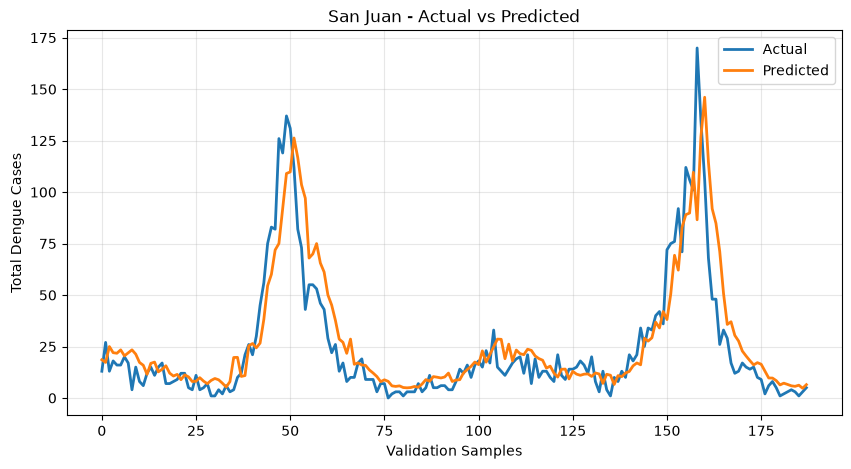

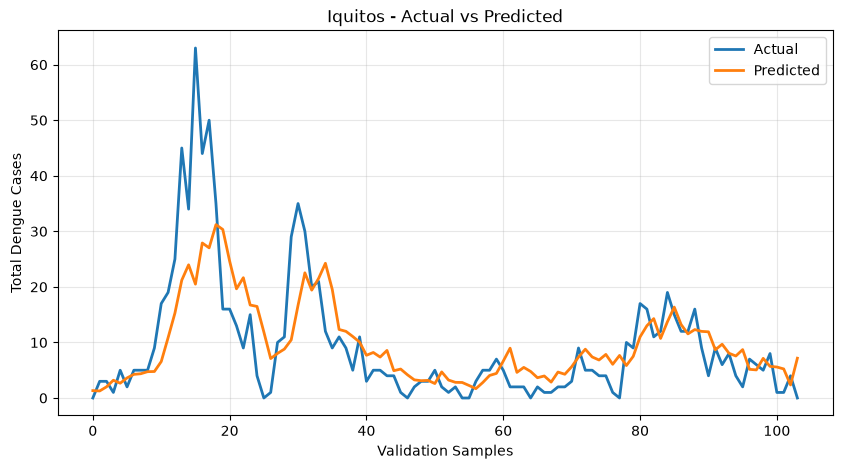

In [145]:
import matplotlib.pyplot as plt

# =========================
# San Juan - Actual vs Predicted
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    y_valid_sj.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    rf_sj_tuned_pred,
    label="Predicted",
    linewidth=2
)

plt.title("San Juan - Actual vs Predicted")
plt.xlabel("Validation Samples")
plt.ylabel("Total Dengue Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# =========================
# Iquitos - Actual vs Predicted
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    y_valid_iq.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    rf_iq_tuned_pred,
    label="Predicted",
    linewidth=2
)

plt.title("Iquitos - Actual vs Predicted")
plt.xlabel("Validation Samples")
plt.ylabel("Total Dengue Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<h3 style="
    color:#1565C0;
    font-size:23px;
    font-weight:700;
    border-left:5px solid #00ACC1;
    padding-left:12px;
">
    Prediction Error Distribution
</h3>

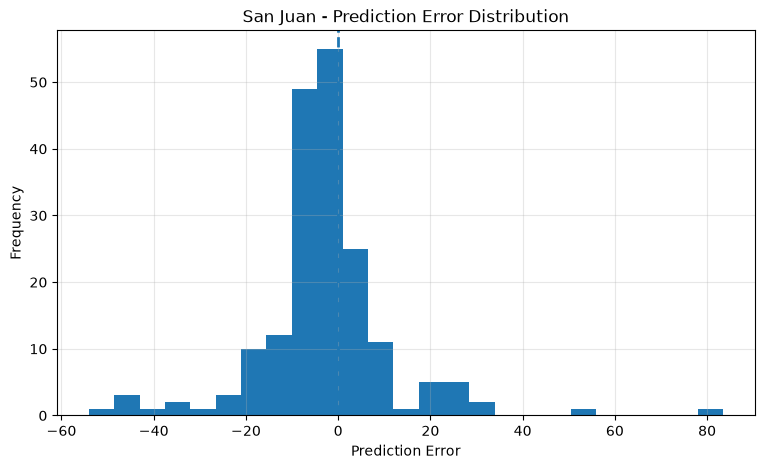

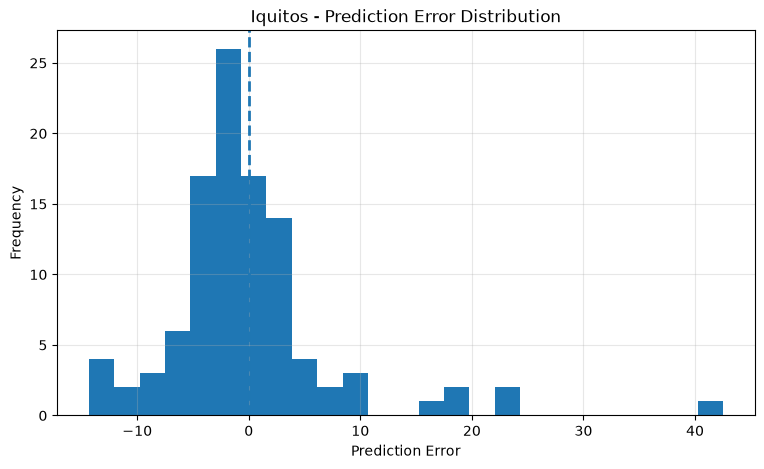

In [146]:
# =========================
# Prediction Errors
# =========================

sj_errors = y_valid_sj.values - rf_sj_tuned_pred
iq_errors = y_valid_iq.values - rf_iq_tuned_pred


# =========================
# San Juan Error Distribution
# =========================

plt.figure(figsize=(9, 5))

plt.hist(
    sj_errors,
    bins=25
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("San Juan - Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()


# =========================
# Iquitos Error Distribution
# =========================

plt.figure(figsize=(9, 5))

plt.hist(
    iq_errors,
    bins=25
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("Iquitos - Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

<h3 style="
    color:#1565C0;
    font-size:23px;
    font-weight:700;
    border-left:5px solid #00ACC1;
    padding-left:12px;
">
    Largest Prediction Errors
</h3>

In [147]:
# =========================
# San Juan - Largest Errors
# =========================

sj_error_analysis = pd.DataFrame({
    "Actual": y_valid_sj.values,
    "Predicted": rf_sj_tuned_pred
})

sj_error_analysis["Error"] = (
    sj_error_analysis["Actual"]
    - sj_error_analysis["Predicted"]
)

sj_error_analysis["Absolute_Error"] = (
    sj_error_analysis["Error"].abs()
)

sj_largest_errors = (
    sj_error_analysis
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

print("===== San Juan Largest Errors =====")
display(sj_largest_errors)


# =========================
# Iquitos - Largest Errors
# =========================

iq_error_analysis = pd.DataFrame({
    "Actual": y_valid_iq.values,
    "Predicted": rf_iq_tuned_pred
})

iq_error_analysis["Error"] = (
    iq_error_analysis["Actual"]
    - iq_error_analysis["Predicted"]
)

iq_error_analysis["Absolute_Error"] = (
    iq_error_analysis["Error"].abs()
)

iq_largest_errors = (
    iq_error_analysis
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

print("===== Iquitos Largest Errors =====")
display(iq_largest_errors)

===== San Juan Largest Errors =====


,Actual,Predicted,Error,Absolute_Error
158,170,86.566486,83.433514,83.433514
54,43,97.052936,-54.052936,54.052936
47,126,75.039535,50.960465,50.960465
161,68,114.590890,-46.590890,46.590890
164,26,71.156897,-45.156897,45.156897
162,48,91.922646,-43.922646,43.922646
160,106,146.079212,-40.079212,40.079212
163,48,84.837401,-36.837401,36.837401
52,82,116.761025,-34.761025,34.761025
150,72,38.106486,33.893514,33.893514


===== Iquitos Largest Errors =====


,Actual,Predicted,Error,Absolute_Error
15,63,20.494924,42.505076,42.505076
13,45,21.206429,23.793571,23.793571
17,50,27.027782,22.972218,22.972218
29,29,10.459296,18.540704,18.540704
30,35,16.679421,18.320579,18.320579
16,44,27.899971,16.100029,16.100029
19,16,30.331567,-14.331567,14.331567
22,9,21.653782,-12.653782,12.653782
24,4,16.481363,-12.481363,12.481363
34,12,24.247655,-12.247655,12.247655


<h2 style="
    color:#7B1FA2;
    font-size:27px;
    font-weight:700;
    border-left:6px solid #E91E63;
    padding-left:14px;
">
    Final Model Selection
</h2>

### Final Model Decision

After evaluating multiple regression models with temporal lag features, the original Random Forest model achieved the best overall validation performance for both San Juan and Iquitos.

The hyperparameter-tuned Random Forest did not improve the validation results. Instead, it produced higher MAE and RMSE values and lower R² scores compared with the original Random Forest.

The error analysis also showed that the tuned model struggled with several high-error observations and peak dengue case values.

Therefore, the original Random Forest with lag features was selected as the final modeling approach.

Separate Random Forest models were trained for San Juan and Iquitos to account for the different temporal and environmental patterns of the two cities.

<h1 style="
    background: linear-gradient(135deg, #4A148C, #7B1FA2, #E91E63);
    color:#FFFFFF;
    padding:24px;
    border-radius:18px;
    text-align:center;
    font-size:34px;
    font-weight:700;
    box-shadow:0 8px 25px rgba(74,20,140,0.35);
    letter-spacing:1.2px;
">
    Finalization
</h1>

## Final Random Forest

Based on the validation results and model comparison, Random Forest with temporal lag features was selected as the final modeling approach.

The model is trained separately for San Juan and Iquitos to account for the different temporal and environmental patterns of dengue cases.

In [152]:
# ==========================================
# Final Dataset Preparation
# ==========================================

sj_final = sj_train.copy()
iq_final = iq_train.copy()

print("San Juan final data:", sj_final.shape)
print("Iquitos final data:", iq_final.shape)

San Juan final data: (936, 29)
Iquitos final data: (520, 29)


In [153]:
# ==========================================
# Remove rows with missing lag features
# ==========================================

sj_final = sj_final.dropna(
    subset=lag_cols
).copy()

iq_final = iq_final.dropna(
    subset=lag_cols
).copy()

print("San Juan final after lag cleanup:", sj_final.shape)
print("Iquitos final after lag cleanup:", iq_final.shape)

San Juan final after lag cleanup: (924, 29)
Iquitos final after lag cleanup: (508, 29)


In [154]:
# ==========================================
# Prepare Final X and y
# ==========================================

X_sj_final = sj_final.drop(
    columns=["total_cases"]
)

y_sj_final = sj_final["total_cases"]

X_iq_final = iq_final.drop(
    columns=["total_cases"]
)

y_iq_final = iq_final["total_cases"]

print("SJ Features:", X_sj_final.shape)
print("IQ Features:", X_iq_final.shape)

SJ Features: (924, 28)
IQ Features: (508, 28)


In [155]:
from sklearn.impute import SimpleImputer

# ==========================================
# Final Imputation
# ==========================================

imputer_sj_final = SimpleImputer(strategy="median")
imputer_iq_final = SimpleImputer(strategy="median")

X_sj_final = imputer_sj_final.fit_transform(
    X_sj_final
)

X_iq_final = imputer_iq_final.fit_transform(
    X_iq_final
)

print("SJ NaN:", np.isnan(X_sj_final).sum())
print("IQ NaN:", np.isnan(X_iq_final).sum())

SJ NaN: 0
IQ NaN: 0


# Final Random Forest

In [156]:
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# Final Random Forest Models
# ==========================================

rf_sj_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_iq_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# ==========================================
# Train on ALL available data
# ==========================================

rf_sj_final.fit(
    X_sj_final,
    y_sj_final
)

rf_iq_final.fit(
    X_iq_final,
    y_iq_final
)

print("Final Random Forest models trained successfully!")

Final Random Forest models trained successfully!


In [157]:
# ==========================================
# Final Prediction Sanity Check
# ==========================================

sj_final_predictions = rf_sj_final.predict(X_sj_final)
iq_final_predictions = rf_iq_final.predict(X_iq_final)

print("San Juan final predictions:")
print(sj_final_predictions[:5])

print("\nIquitos final predictions:")
print(iq_final_predictions[:5])

San Juan final predictions:
[ 6.02       14.62       19.96666667 16.39666667 20.78      ]

Iquitos final predictions:
[0.25666667 0.12       0.00666667 0.68333333 0.81333333]


In [158]:
import joblib
import os

# ==========================================
# Save Final Models
# ==========================================

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_sj_final,
    "../models/random_forest_san_juan_final.joblib"
)

joblib.dump(
    rf_iq_final,
    "../models/random_forest_iquitos_final.joblib"
)

print("Final models saved successfully!")

Final models saved successfully!


In [159]:
print(
    "San Juan model:",
    os.path.exists("../models/random_forest_san_juan_final.joblib")
)

print(
    "Iquitos model:",
    os.path.exists("../models/random_forest_iquitos_final.joblib")
)

San Juan model: True
Iquitos model: True


# Load Verification

In [160]:
import joblib

# ==========================================
# Load Saved Final Models
# ==========================================

rf_sj_loaded = joblib.load(
    "../models/random_forest_san_juan_final.joblib"
)

rf_iq_loaded = joblib.load(
    "../models/random_forest_iquitos_final.joblib"
)

print(
    "San Juan model loaded:",
    type(rf_sj_loaded).__name__
)

print(
    "Iquitos model loaded:",
    type(rf_iq_loaded).__name__
)

San Juan model loaded: RandomForestRegressor
Iquitos model loaded: RandomForestRegressor


In [161]:
# ==========================================
# Loaded Model Prediction Test
# ==========================================

sj_loaded_pred = rf_sj_loaded.predict(X_sj_final)
iq_loaded_pred = rf_iq_loaded.predict(X_iq_final)

print("San Juan loaded-model predictions:")
print(sj_loaded_pred[:5])

print("\nIquitos loaded-model predictions:")
print(iq_loaded_pred[:5])

San Juan loaded-model predictions:
[ 6.02       14.62       19.96666667 16.39666667 20.78      ]

Iquitos loaded-model predictions:
[0.25666667 0.12       0.00666667 0.68333333 0.81333333]


<h1 style="
    background: linear-gradient(135deg, #6A1B9A, #E91E63);
    color: white;
    padding: 18px;
    border-radius: 14px;
    text-align: center;
    font-size: 30px;
    font-weight: 700;
">
    Final Project Summary
</h1>

## Project Overview

This notebook documents the complete development process of the DengAI forecasting model, from data understanding and preprocessing to feature engineering, model comparison, error analysis, and final model deployment preparation.

### Key Steps Completed

1. **Data Understanding & Exploration**
   - Examined the structure, distributions, missing values, and relationships within the DengAI dataset.
   - Analyzed the two target cities separately: **San Juan** and **Iquitos**.
   - Investigated temporal patterns and environmental variables related to dengue cases.

2. **Data Preprocessing**
   - Cleaned the training data and handled missing values.
   - Created additional features such as:
     - `month`
     - `ndvi_mean`
     - `temp_range`
   - Maintained chronological ordering to respect the time-series nature of the problem.

3. **Lag Feature Engineering**
   - Introduced historical dengue case information through lag features:
     - `cases_lag_1`
     - `cases_lag_2`
     - `cases_lag_4`
     - `cases_lag_12`
   - These features significantly improved the model's ability to capture temporal dependencies.

4. **Model Development & Comparison**
   - Several regression approaches were evaluated during the experimentation stage.
   - Random Forest and XGBoost were compared based on validation performance.
   - Although XGBoost is often a strong choice for tabular data, model selection was based on the actual validation results of this dataset rather than assuming that one algorithm is always superior.

5. **Model Selection**
   - The final selected approach was **Random Forest Regression with Lag Features**.
   - The model achieved the strongest validation performance among the tested approaches.

   **Validation Results:**

   | City | MAE | RMSE | R² |
   |------|-----|------|-----|
   | San Juan | 7.3211 | 11.0796 | 0.8737 |
   | Iquitos | 4.3499 | 6.8189 | 0.6434 |

6. **Error Analysis**
   - Compared actual and predicted dengue cases.
   - Visualized prediction behavior using Actual vs. Predicted plots.
   - Investigated the largest prediction errors to understand where the model struggled.
   - This analysis helped confirm that the selected model was reasonable while also identifying cases with larger deviations.

7. **Final Model Training**
   - After model selection and validation, the final Random Forest models were retrained using the available city-specific data.
   - The final models use the same feature engineering and preprocessing strategy established during experimentation.

8. **Final Model Verification**
   - The trained models were saved as `.joblib` files.
   - The saved models were loaded again successfully.
   - Predictions generated before and after saving/loading were consistent, confirming that the saved models are valid and ready for deployment.

### Final Models

The project now contains two city-specific Random Forest models:

- **San Juan:** `random_forest_san_juan_final.joblib`
- **Iquitos:** `random_forest_iquitos_final.joblib`

### Final Status

The modeling stage is complete.

The selected models have been trained, validated, analyzed, saved, and successfully reloaded for prediction.

The next stage is to integrate the final models into a **Streamlit application** and prepare the project for public deployment.

In [164]:
import os

print(os.getcwd())

c:\Users\Rahma mohamed\OneDrive\Desktop\AI-Portfolio\3__DengAI\notebooks


In [165]:
import os

os.makedirs("../models", exist_ok=True)

In [166]:
import joblib

joblib.dump(
    imputer_sj,
    "../models/imputer_san_juan_final.joblib"
)

joblib.dump(
    imputer_iq,
    "../models/imputer_iquitos_final.joblib"
)

print("Imputers saved successfully!")

Imputers saved successfully!
